# Beyond Binary: Four-Class Risk Stratification from Gastrointestinal Endoscopy Using Asymmetric-Cost Lightweight CNN–Transformer Learning
## DenseNet-121 · EfficientNet-B0 · DeiT-Tiny | Asymmetric Endoscopy Loss | GradCAM | MC Dropout

**Author:** Azizur Rahman  
**Affiliation:** Indiana Wesleyan University · RadTH Technologies  
**Target Venue:** Medical & Biological Engineering & Computing (MBEC), Springer 11517

---
### Notebook Contents
| # | Section |
|---|----------|
| 1 | Environment Setup |
| 2 | Dataset Loading & 4-Class Label Mapping |
| 3 | Data Augmentation & DataLoader |
| 4 | Model Architecture — DenseNet-121 · EfficientNet-B0 · DeiT-Tiny |
| 5 | Asymmetric Endoscopy Loss (AEL) |
| 6 | Training (one cell per model, checkpoint-safe) |
| 7 | AEL Ablation Study (single-seed reference run) |
| 8 | Cross-Dataset Evaluation — Kvasir-v2 zero-shot |
| 9 | ROC-AUC Curves |
| 10 | GradCAM Explainability |
| 11 | Monte Carlo Dropout Uncertainty |
| 12 | Endoscopist Workload Simulation |
| 13 | Multi-Seed Ablation — AEL vs CE vs Focal (Table 12) |
| 14 | Multi-Seed AEL Sensitivity — HR Weight Sweep (Table 11) |
| 15 | Model Calibration — ECE & Reliability Diagrams |
| 16 | Results Summary & Paper Tables |

---
> **To reproduce paper results end-to-end:**  
> 1. Download HyperKvasir labeled-images → `data/HyperKvasir/labeled-images/`  
> 2. Download Kvasir-v2 → `data/Kvasir-v2/`  
> 3. Run cells top-to-bottom (each section is independent; checkpoints are saved after training)  
> 4. Sections 13–14 take ~2–4 h each on MPS/GPU — results print LaTeX rows for Tables 11 & 12

## 1. Environment Setup

In [1]:
!pip install torch torchvision timm
!pip install scikit-learn pandas numpy matplotlib seaborn tqdm
!pip install grad-cam opencv-python pillow
!pip install statsmodels scipy
!pip install nbformat

In [2]:
import os as _os
PROJECT_DIR = _os.path.dirname(_os.path.abspath('GastroEndoscopy_Risk_Stratification.ipynb'))
CKPT_DIR    = _os.path.join(PROJECT_DIR, 'checkpoints')
print(f'Project dir: {PROJECT_DIR}')

import os, random, warnings, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ─────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# ── Global hyperparameters ─────────────────────────────────────────────────────
NUM_CLASSES  = 4
IMG_SIZE     = 224
BATCH_SIZE   = 32

# ── CLAHE config ───────────────────────────────────────────────────────────────
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE  = (8, 8)

# ── AEL class weights (ACG/ESGE clinical cost asymmetry) ──────────────────────
# Inflammatory raised 2.0 → 3.5 to address small class size (645 images)
AEL_WEIGHTS = [1.0, 3.5, 3.0, 5.0]   # Normal, Inflammatory, Pre-malignant, High-Risk

# ── Per-model dropout rates ────────────────────────────────────────────────────
DROPOUT_RATES = {
    'densenet121':     0.5,
    'efficientnet_b0': 0.3,
    'deit_tiny':       0.1,
}

LABEL_NAMES  = ['Normal', 'Inflammatory', 'Pre_malignant', 'High_Risk']
RISK_LABELS  = ['Routine Surveillance', 'Medical Management',
                'Biopsy + Surveillance', 'Immediate Intervention']
RISK_ACTIONS = [
    'Continue standard screening interval',
    'Medical treatment + annual endoscopy',
    'Biopsy required + 3-6 month follow-up',
    'Resection or oncology referral',
]

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Seeds  : SEED={SEED}  cudnn.deterministic=True')
print(f'AEL weights: {AEL_WEIGHTS}  (Inflammatory raised to 3.5)')
print(f'\n4-Class Clinical Risk Schema (ACG/ESGE Aligned):')
for i in range(NUM_CLASSES):
    print(f'  Class {i} | {LABEL_NAMES[i]:<18} → {RISK_LABELS[i]}')

Project dir: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification
Device : cuda
PyTorch: 2.13.0+cu126
Seeds  : SEED=42  cudnn.deterministic=True
AEL weights: [1.0, 3.5, 3.0, 5.0]  (Inflammatory raised to 3.5)

4-Class Clinical Risk Schema (ACG/ESGE Aligned):
  Class 0 | Normal             → Routine Surveillance
  Class 1 | Inflammatory       → Medical Management
  Class 2 | Pre_malignant      → Biopsy + Surveillance
  Class 3 | High_Risk          → Immediate Intervention


## 2. Dataset Loading & 4-Class Label Mapping

HyperKvasir contains 110,079 images across 23 GI finding classes.
We map these to 4 clinical risk tiers following ACG/ESGE guidelines.

| Risk Class | HyperKvasir Folders |
|---|---|
| 0 Normal | normal-cecum, normal-pylorus, normal-z-line, retroflex-stomach, retroflex-rectum, ileum, bbps-2-3 |
| 1 Inflammatory | esophagitis-a, ulcerative-colitis-grade-0-1, ulcerative-colitis-grade-1, hemorrhoids |
| 2 Pre-malignant | barretts, barretts-short-segment, esophagitis-b-d, polyp, ulcerative-colitis-grade-1-2, ulcerative-colitis-grade-2 |
| 3 High-Risk | ulcerative-colitis-grade-2-3, ulcerative-colitis-grade-3, dyed-lifted-polyps, dyed-resection-margins |


In [3]:
# Actual HyperKvasir folder names (verified from extracted archive)
HYPERKVASIR_MAP = {
    # Class 0 — Normal / Routine Surveillance
    'cecum':             0,   # lower-gi-tract/anatomical-landmarks
    'pylorus':           0,   # upper-gi-tract/anatomical-landmarks
    'z-line':            0,   # upper-gi-tract/anatomical-landmarks
    'retroflex-stomach': 0,
    'retroflex-rectum':  0,
    'ileum':             0,
    'bbps-2-3':          0,
    # Class 1 — Inflammatory / Low-Risk
    'esophagitis-a':                1,
    'ulcerative-colitis-grade-0-1': 1,
    'ulcerative-colitis-grade-1':   1,
    'hemorrhoids':                  1,
    # Class 2 — Pre-malignant / Moderate-Risk
    'barretts':                     2,
    'barretts-short-segment':       2,
    'esophagitis-b-d':              2,
    'polyps':                       2,   # actual folder name is 'polyps' not 'polyp'
    'ulcerative-colitis-grade-1-2': 2,
    'ulcerative-colitis-grade-2':   2,
    # Class 3 — High-Risk / Immediate Intervention
    'ulcerative-colitis-grade-2-3': 3,
    'ulcerative-colitis-grade-3':   3,
    'dyed-lifted-polyps':           3,
    'dyed-resection-margins':       3,
}

EXCLUDED_CLASSES = {'bbps-0-1', 'impacted-stool', 'out-of-patient', 'short-segment-barretts'}


def load_hyperkvasir(data_dir: str, max_normal: int = 3000) -> pd.DataFrame:
    """
    Walk the nested HyperKvasir structure:
      labeled-images/<tract>/<category>/<class-folder>/<images>
    and map every class folder to a 4-class clinical risk tier.
    """
    rng      = random.Random(SEED)
    base_dir = os.path.join(data_dir, 'labeled-images')

    if not os.path.exists(base_dir):
        print(f'[!] HyperKvasir not found at {base_dir}')
        return pd.DataFrame(columns=['image_path', 'label', 'label_name', 'risk', 'source_class'])

    normal_paths, other_rows, skipped = [], [], []

    # Walk all subdirectories — class folders sit at depth 3 (tract/category/class)
    for root, dirs, files in os.walk(base_dir):
        depth = root.replace(base_dir, '').count(os.sep)
        if depth != 3:
            continue
        class_folder = os.path.basename(root)
        if class_folder in EXCLUDED_CLASSES:
            continue
        label = HYPERKVASIR_MAP.get(class_folder)
        if label is None:
            skipped.append(class_folder)
            continue
        imgs = [os.path.join(root, f) for f in files
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        for path in imgs:
            row = {'image_path': path, 'label': label,
                   'label_name': LABEL_NAMES[label], 'risk': RISK_LABELS[label],
                   'source_class': class_folder}
            (normal_paths if label == 0 else other_rows).append(row)

    if skipped:
        print(f'[INFO] Skipped {len(skipped)} unmapped folders: {", ".join(sorted(skipped))}')

    if len(normal_paths) > max_normal:
        print(f'[INFO] Normal class capped: {len(normal_paths)} → {max_normal} images')
        rng.shuffle(normal_paths)
        normal_paths = normal_paths[:max_normal]

    df = pd.DataFrame(normal_paths + other_rows)
    if len(df) == 0:
        print('[!] No images found. Check data directory and folder structure.')
        return df

    print(f'\nHyperKvasir loaded: {len(df)} images across {df["source_class"].nunique()} classes')
    print('\nRisk-tier distribution:')
    for label in range(NUM_CLASSES):
        subset = df[df['label'] == label]
        print(f'  Class {label} | {LABEL_NAMES[label]:<20}: {len(subset):>5}  ({100*len(subset)/len(df):.1f}%)')
    return df


DATA_ROOT = 'data/HyperKvasir'
df = load_hyperkvasir(DATA_ROOT, max_normal=3000)

if len(df) > 0:
    train_df, temp  = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=SEED)
    print(f'\nSplit: train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')

[INFO] Normal class capped: 5252 → 3000 images

HyperKvasir loaded: 7633 images across 21 classes

Risk-tier distribution:
  Class 0 | Normal              :  3000  (39.3%)
  Class 1 | Inflammatory        :   645  (8.5%)
  Class 2 | Pre_malignant       :  1836  (24.1%)
  Class 3 | High_Risk           :  2152  (28.2%)

Split: train=5343  val=1145  test=1145


In [4]:
def visualize_dataset_samples(data_dir, label_map, label_names, n_per_class=4, title='Dataset Samples'):
    """Sample images per risk class with solid colored sidebar labels (GridSpec layout)."""
    from collections import defaultdict
    import matplotlib.gridspec as _gs

    if not os.path.exists(data_dir):
        print(f'[!] Directory not found: {data_dir}'); return

    class_images = defaultdict(list)
    for root, _, files in os.walk(data_dir):
        folder = os.path.basename(root)
        label  = label_map.get(folder)
        if label is None:
            continue
        class_images[label].extend(
            os.path.join(root, f) for f in files
            if f.lower().endswith(('.jpg', '.jpeg', '.png')))

    n_classes = len(label_names)
    colors    = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']

    fig = plt.figure(figsize=(n_per_class * 2.8 + 1.4, n_classes * 2.8))
    fig.suptitle(f'{title} — Sample Images per Risk Class', fontsize=13, fontweight='bold', y=1.01)

    gs = fig.add_gridspec(
        n_classes, n_per_class + 1,
        width_ratios=[0.38] + [1] * n_per_class,
        hspace=0.06, wspace=0.04,
        top=0.96, bottom=0.02, left=0.02, right=0.98
    )

    for cls in range(n_classes):
        # Solid colored sidebar with white class name
        ax_lbl = fig.add_subplot(gs[cls, 0])
        ax_lbl.set_facecolor(colors[cls])
        ax_lbl.text(0.5, 0.5, label_names[cls],
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white', rotation=90, transform=ax_lbl.transAxes)
        ax_lbl.set_xticks([]); ax_lbl.set_yticks([])
        for spine in ax_lbl.spines.values(): spine.set_visible(False)

        imgs   = class_images.get(cls, [])
        sample = random.sample(imgs, min(n_per_class, len(imgs)))

        for col in range(n_per_class):
            ax = fig.add_subplot(gs[cls, col + 1])
            if col < len(sample):
                try:    ax.imshow(Image.open(sample[col]).convert('RGB'))
                except: ax.set_facecolor('#cccccc')
            else:
                ax.set_facecolor('#cccccc')
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(colors[cls])
                spine.set_linewidth(1.5)

    out = os.path.join(PROJECT_DIR, f'samples_{title.replace(" ","_").lower()}.png')
    plt.savefig(out, dpi=120, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {out}')

print('visualize_dataset_samples() ready.')

visualize_dataset_samples() ready.


In [5]:
def plot_class_distribution(data_dir, label_map, label_names, title='Class Distribution'):
    from collections import defaultdict
    counts = defaultdict(int)

    if not os.path.exists(data_dir):
        print(f'[!] Directory not found: {data_dir}'); return

    # os.walk handles both flat (Kvasir-v2) and nested (HyperKvasir) structures
    for root, dirs, files in os.walk(data_dir):
        folder_name = os.path.basename(root)
        label = label_map.get(folder_name)
        if label is None:
            continue
        counts[label] += sum(1 for f in files
                             if f.lower().endswith(('.jpg', '.jpeg', '.png')))

    total = sum(counts.values())
    if total == 0:
        print(f'[!] No images found in {data_dir}'); return

    colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    bars = axes[0].bar([label_names[i] for i in range(len(label_names))],
                       [counts[i] for i in range(len(label_names))],
                       color=colors, alpha=0.85, edgecolor='white')
    for bar, i in zip(bars, range(len(label_names))):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f'{counts[i]}\n({100*counts[i]/total:.1f}%)',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].set(ylabel='Image Count', title=title)
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].pie([counts[i] for i in range(len(label_names))],
                labels=label_names, colors=colors, autopct='%1.1f%%',
                startangle=90, pctdistance=0.8)
    axes[1].set_title(f'{title} — Pie')

    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'dist_{title.replace(" ","_").lower()}.png'), dpi=100, bbox_inches='tight')
    plt.show()

print('plot_class_distribution() ready.')

plot_class_distribution() ready.


In [6]:
# Visualize Kvasir-v2 samples
# NOTE: run after Section 8 defines KVASIR_V2_MAP, or run Section 8 cell first
if 'KVASIR_V2_MAP' not in globals():
    print('[!] Run the KVASIR_V2_MAP cell in Section 8 first, then re-run this cell.')
else:
    visualize_dataset_samples('data/Kvasir-v2', KVASIR_V2_MAP, LABEL_NAMES,
                              n_per_class=4, title='Kvasir-v2')

[!] Run the KVASIR_V2_MAP cell in Section 8 first, then re-run this cell.


In [7]:
# Kvasir-v2 class distribution
# NOTE: run after Section 8 defines KVASIR_V2_MAP, or run Section 8 cell first
if 'KVASIR_V2_MAP' not in globals():
    print('[!] Run the KVASIR_V2_MAP cell in Section 8 first, then re-run this cell.')
else:
    plot_class_distribution('data/Kvasir-v2', KVASIR_V2_MAP, LABEL_NAMES,
                            title='Kvasir-v2 — Class Distribution')

[!] Run the KVASIR_V2_MAP cell in Section 8 first, then re-run this cell.


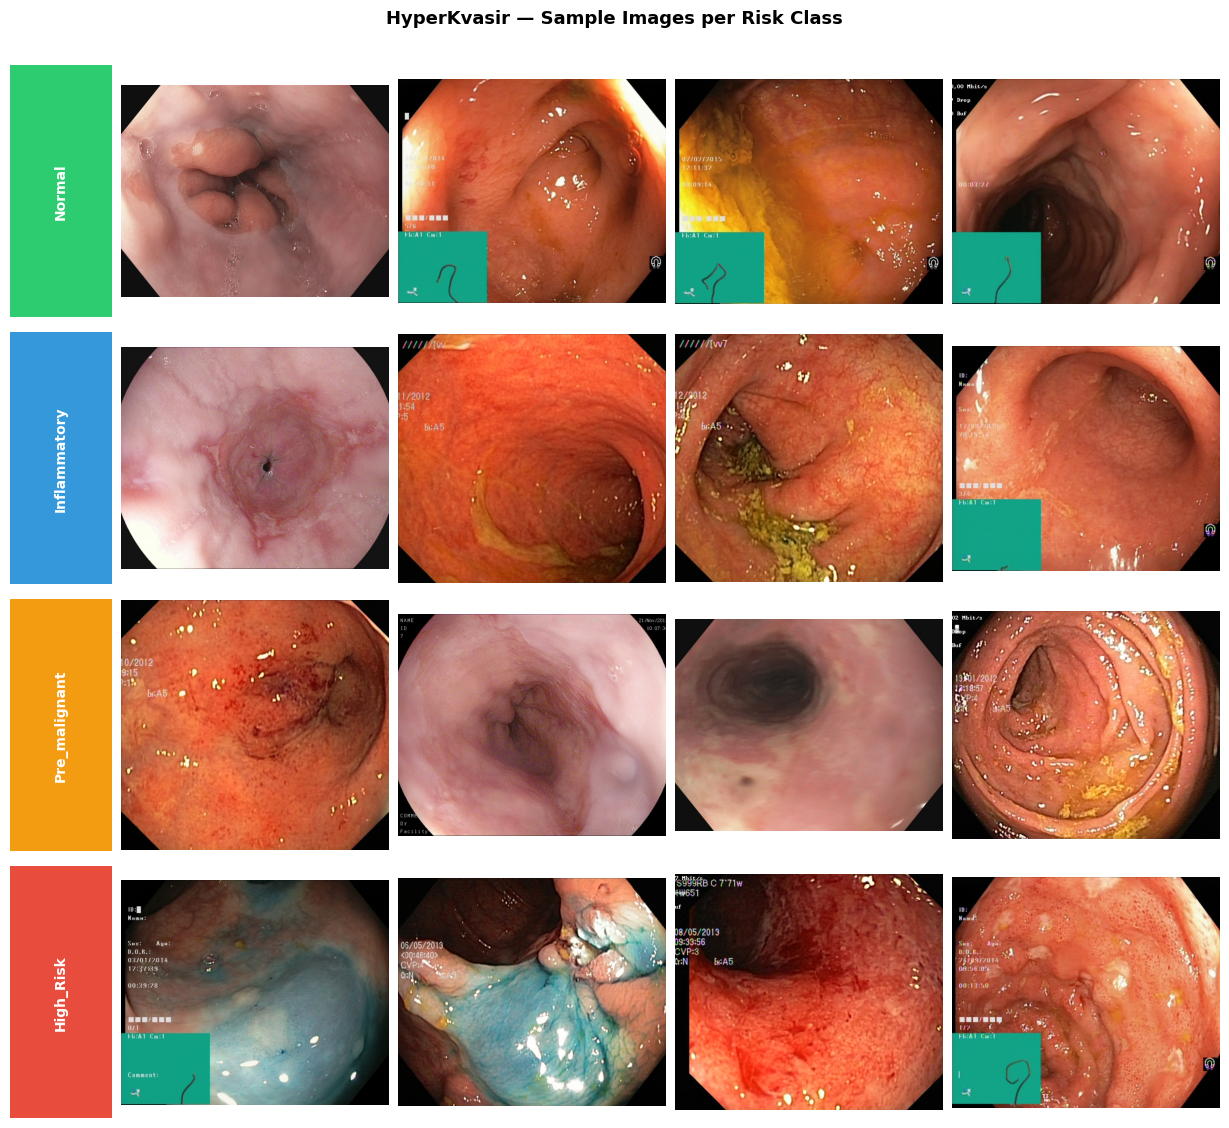

Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\samples_hyperkvasir.png


In [8]:
# Visualize HyperKvasir samples (run after extraction)
visualize_dataset_samples('data/HyperKvasir/labeled-images', HYPERKVASIR_MAP, LABEL_NAMES,
                           n_per_class=4, title='HyperKvasir')

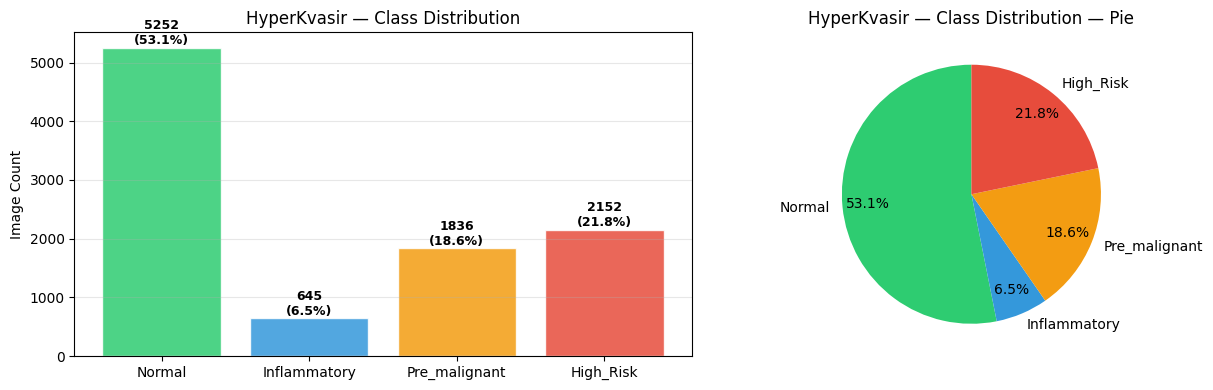

In [9]:
# HyperKvasir class distribution (run after extraction)
plot_class_distribution('data/HyperKvasir/labeled-images', HYPERKVASIR_MAP, LABEL_NAMES,
                         title='HyperKvasir — Class Distribution')

Executing <Handle BaseAsyncIOLoop._handle_events(1872, 1) created at C:\Program Files\Python312\Lib\asyncio\selector_events.py:276> took 0.172 seconds
Executing <Handle BaseAsyncIOLoop._handle_events(1940, 1) created at C:\Program Files\Python312\Lib\asyncio\selector_events.py:276> took 0.203 seconds


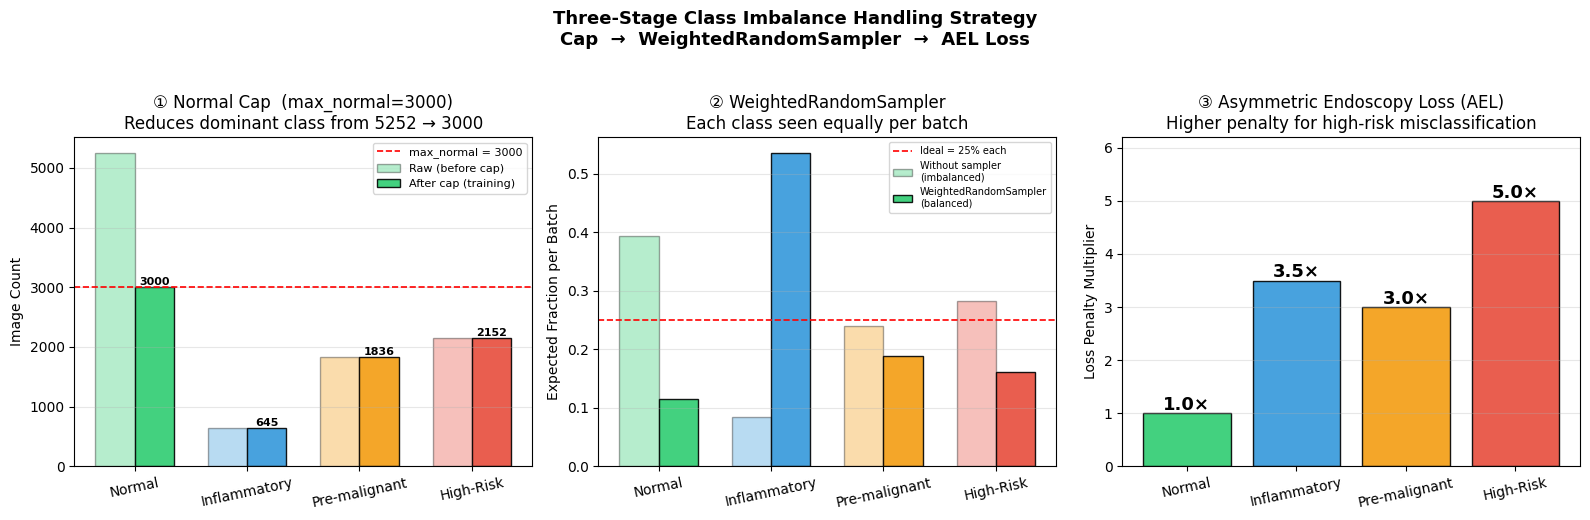

Saved → imbalance_handling.png


In [10]:
def plot_imbalance_handling():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    labels = ['Normal', 'Inflammatory', 'Pre-malignant', 'High-Risk']
    x = np.arange(len(labels))
    w = 0.35

    # ── Panel 1: Raw vs Capped ────────────────────────────────────────────────
    raw    = [5252, 645, 1836, 2152]
    capped = [3000, 645, 1836, 2152]
    axes[0].bar(x - w/2, raw,    w, label='Raw (before cap)',    color=colors, alpha=0.35, edgecolor='black')
    axes[0].bar(x + w/2, capped, w, label='After cap (training)', color=colors, alpha=0.9,  edgecolor='black')
    for i, val in enumerate(capped):
        axes[0].text(x[i] + w/2, val + 30, str(val), ha='center', fontsize=8, fontweight='bold')
    axes[0].axhline(3000, color='red', linestyle='--', linewidth=1.2, label='max_normal = 3000')
    axes[0].set(xticks=x, xticklabels=labels, ylabel='Image Count',
                title='① Normal Cap  (max_normal=3000)\nReduces dominant class from 5252 → 3000')
    axes[0].tick_params(axis='x', rotation=12); axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

    # ── Panel 2: WeightedRandomSampler — expected probability per batch ───────
    counts      = np.array([3000, 645, 1836, 2152], dtype=float)
    proportional = counts / counts.sum()
    inv_w        = 1.0 / counts
    balanced     = inv_w / inv_w.sum()
    axes[1].bar(x - w/2, proportional, w, label='Without sampler\n(imbalanced)', color=colors, alpha=0.35, edgecolor='black')
    axes[1].bar(x + w/2, balanced,     w, label='WeightedRandomSampler\n(balanced)',  color=colors, alpha=0.9,  edgecolor='black')
    axes[1].axhline(0.25, color='red', linestyle='--', linewidth=1.2, label='Ideal = 25% each')
    axes[1].set(xticks=x, xticklabels=labels, ylabel='Expected Fraction per Batch',
                title='② WeightedRandomSampler\nEach class seen equally per batch')
    axes[1].tick_params(axis='x', rotation=12); axes[1].legend(fontsize=7); axes[1].grid(axis='y', alpha=0.3)

    # ── Panel 3: AEL class weights ────────────────────────────────────────────
    ael = [1.0, 3.5, 3.0, 5.0]
    bars = axes[2].bar(labels, ael, color=colors, alpha=0.9, edgecolor='black')
    for bar, val in zip(bars, ael):
        axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.06,
                     f'{val}×', ha='center', fontsize=13, fontweight='bold')
    axes[2].set(ylabel='Loss Penalty Multiplier', ylim=(0, 6.2),
                title='③ Asymmetric Endoscopy Loss (AEL)\nHigher penalty for high-risk misclassification')
    axes[2].tick_params(axis='x', rotation=12); axes[2].grid(axis='y', alpha=0.3)

    plt.suptitle('Three-Stage Class Imbalance Handling Strategy\n'
                 'Cap  →  WeightedRandomSampler  →  AEL Loss',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'imbalance_handling.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → imbalance_handling.png')

plot_imbalance_handling()

## 3. Data Augmentation & DataLoader

Preprocessing pipeline:
```
Image → CLAHE Enhancement → Resize → Augmentation → Normalize → Tensor
```

CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances mucosal texture,
vascular patterns, and pit structures critical for risk-level discrimination.


In [11]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Tolerate partially-extracted images

class CLAHETransform:
    """CLAHE on the L-channel of LAB space to enhance mucosal texture."""
    def __init__(self, clip_limit=CLAHE_CLIP_LIMIT, tile_grid_size=CLAHE_TILE_SIZE):
        self.clip_limit     = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        try:
            img_np = np.array(img.convert('RGB'))
            clahe  = cv2.createCLAHE(clipLimit=self.clip_limit,
                                      tileGridSize=self.tile_grid_size)
            lab        = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            lab[..., 0] = clahe.apply(lab[..., 0])
            img_np     = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_np)
        except Exception as e:
            warnings.warn(f'CLAHETransform failed ({e}); returning original image.')
            return img


DATASET_MEAN = [0.485, 0.456, 0.406]
DATASET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

val_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

_BLANK = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))


class EndoscopyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        missing = set(p for p in self.df['image_path'] if not os.path.exists(p))
        if missing:
            warnings.warn(f'{len(missing)} image paths not found — those rows will return blank images.')
            self.df = self.df[~self.df['image_path'].isin(missing)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except Exception as e:
            warnings.warn(f"Bad image skipped: {e}")
            img = _BLANK.copy()
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['label'], dtype=torch.long)


def make_loaders(train_df, val_df, test_df):
    counts  = train_df['label'].value_counts().sort_index().values
    weights = 1.0 / counts
    sw      = torch.tensor(weights[train_df['label'].values], dtype=torch.float64)
    sampler = WeightedRandomSampler(
        sw, num_samples=len(sw), replacement=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    pin = DEVICE.type == 'cuda'
    train_ldr = DataLoader(EndoscopyDataset(train_df, train_transforms),
                           BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=pin)
    val_ldr   = DataLoader(EndoscopyDataset(val_df,   val_transforms),
                           BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=pin)
    test_ldr  = DataLoader(EndoscopyDataset(test_df,  val_transforms),
                           BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=pin)
    return train_ldr, val_ldr, test_ldr


if len(df) > 0:
    train_ldr, val_ldr, test_ldr = make_loaders(train_df, val_df, test_df)
    print(f'DataLoaders ready: train={len(train_ldr)} batches  val={len(val_ldr)}  test={len(test_ldr)}')
    print('Pipeline: CLAHE -> Resize -> Augment -> Normalize')
    print('Truncated images: PIL loads with gray fill (LOAD_TRUNCATED_IMAGES=True)')
# ── Fast cached preprocessing: decode+CLAHE+Resize ONCE, reused across epochs/runs ──
import hashlib as _hl

EVAL_NORM = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(DATASET_MEAN, DATASET_STD)])


def _preload_cache(df, tag, resize, use_clahe=True):
    """Decode + optional CLAHE + Resize once per dataset; persist uint8 HWC arrays.
    Key includes a content fingerprint so re-splits invalidate automatically."""
    _fp   = _hl.md5(''.join(df['image_path'].tolist()).encode('utf-8')).hexdigest()[:10]
    _path = os.path.join(PROJECT_DIR, 'checkpoints', 'preload',
                         f'{tag}_r{resize}{"_clahe" if use_clahe else ""}_{_fp}.npz')
    os.makedirs(os.path.dirname(_path), exist_ok=True)
    if os.path.exists(_path):
        _d = np.load(_path)
        print(f'[PRELOAD] {tag}: loaded {len(_d["labels"])} imgs (uint8) from disk')
        return _d['imgs'], _d['labels']
    _imgs, _labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Preload {tag}', disable=True):
        img = Image.open(row['image_path']).convert('RGB')
        if use_clahe:
            img = CLAHETransform()(img)
        img = transforms.Resize((resize, resize))(img)   # torchvision resize — bit-identical to train transform
        _imgs.append(np.array(img))                 # H,W,C uint8
        _labels.append(int(row['label']))
    _imgs = np.stack(_imgs)
    np.savez(_path, imgs=_imgs, labels=np.array(_labels, dtype=np.int64))
    print(f'[PRELOAD] {tag}: saved {len(_labels)} imgs -> {_path}')
    return _imgs, _labels


class CachedPILDataset(Dataset):
    """Pre-decoded (post CLAHE+Resize) PIL images, same random-aug pipeline per call.
    Skips disk decode + full-res CLAHE every epoch — the epoch bottleneck."""
    def __init__(self, imgs_arr, labels, transform=None):
        self.imgs = imgs_arr
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = Image.fromarray(self.imgs[i])
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]



DataLoaders ready: train=167 batches  val=36  test=36
Pipeline: CLAHE -> Resize -> Augment -> Normalize
Truncated images: PIL loads with gray fill (LOAD_TRUNCATED_IMAGES=True)


## 4. Model Architecture — DenseNet-121 · EfficientNet-B0 · DeiT-Tiny

Lightweight CNN vs. Transformer benchmark — all models <8M parameters, suitable for real-time inference on endoscopy hardware.

| Model | Type | Pre-training | Parameters | Dropout |
|---|---|---|---|---|
| DenseNet-121 | CNN | ImageNet-1k | 7.0M | 0.5 |
| EfficientNet-B0 | CNN | ImageNet-1k | 5.3M | 0.3 |
| DeiT-Tiny | Transformer | ImageNet-1k | 5.9M | 0.1 |

In [12]:
import timm

def build_densenet121(num_classes=NUM_CLASSES):
    m = models.densenet121(weights='IMAGENET1K_V1')
    m.classifier = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['densenet121']),
        nn.Linear(m.classifier.in_features, num_classes)
    )
    return m

def build_efficientnet_b0(num_classes=NUM_CLASSES):
    m = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    m.classifier = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['efficientnet_b0']),
        nn.Linear(m.num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return m

def build_deit_tiny(num_classes=NUM_CLASSES):
    m = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=0)
    m.head = nn.Sequential(
        nn.Dropout(DROPOUT_RATES['deit_tiny']),
        nn.Linear(m.num_features, num_classes)
    )
    return m

# ── Sanity check ────────────────────────────────────────────────────────────
print('Building model sanity check...')
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE)
for name, fn in [('densenet121', build_densenet121),
                 ('efficientnet_b0', build_efficientnet_b0),
                 ('deit_tiny', build_deit_tiny)]:
    out = fn()(dummy)
    print(f'  {name:20s} → {tuple(out.shape)}  [expect (2, {NUM_CLASSES})]')
del dummy
print('All model builders OK.')


Building model sanity check...
  densenet121          → (2, 4)  [expect (2, 4)]
  efficientnet_b0      → (2, 4)  [expect (2, 4)]
  deit_tiny            → (2, 4)  [expect (2, 4)]
All model builders OK.


## 5. Asymmetric Endoscopy Loss (AEL)

Missing a High-Risk lesion delays resection — survival drops from 90% to <20%.
AEL encodes this clinical cost asymmetry directly into the loss function.

| Class | Weight | Rationale |
|---|---|---|
| Normal (0) | 1.0 | Routine finding — misclassification is low cost |
| Inflammatory (1) | 2.0 | Missed inflammation delays medical treatment |
| Pre-malignant (2) | 3.0 | Missed biopsy allows unmonitored progression |
| High-Risk (3) | 5.0 | Missed intervention = preventable cancer death |


In [13]:
class AsymmetricEndoscopyLoss(nn.Module):
    """
    Weighted cross-entropy encoding ACG/ESGE clinical cost asymmetry.
    Weights are defined globally in AEL_WEIGHTS.
    """
    def __init__(self, weights=None):
        super().__init__()
        w = torch.tensor(weights if weights is not None else AEL_WEIGHTS,
                         dtype=torch.float32).to(DEVICE)
        self.ce = nn.CrossEntropyLoss(weight=w)

    def forward(self, logits, targets):
        return self.ce(logits, targets)


print('Asymmetric Endoscopy Loss (AEL):')
for i, (name, risk, w) in enumerate(zip(LABEL_NAMES, RISK_LABELS, AEL_WEIGHTS)):
    print(f'  Class {i} | {name:<20} weight={w}  →  {risk}')

Asymmetric Endoscopy Loss (AEL):
  Class 0 | Normal               weight=1.0  →  Routine Surveillance
  Class 1 | Inflammatory         weight=3.5  →  Medical Management
  Class 2 | Pre_malignant        weight=3.0  →  Biopsy + Surveillance
  Class 3 | High_Risk            weight=5.0  →  Immediate Intervention


## 6. Training with Transfer Learning

In [14]:
import time


def train_epoch(model, loader, optimizer, scheduler, criterion, device, epoch, total_epochs, scaler):
    """Train one epoch with visible per-batch status and CUDA mixed precision."""
    model.train()
    total_loss, preds_all, trues_all = 0.0, [], []
    use_cuda = device.type == 'cuda'
    start = time.perf_counter()

    for batch_idx, (imgs, labels) in enumerate(loader, start=1):
        imgs = imgs.to(device, non_blocking=use_cuda)
        labels = labels.to(device, non_blocking=use_cuda)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_cuda):
            out = model(imgs)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds_all.extend(out.detach().argmax(1).cpu().numpy())
        trues_all.extend(labels.cpu().numpy())

        elapsed = time.perf_counter() - start
        remaining = elapsed * (len(loader) - batch_idx) / batch_idx
        print(
            f'    Epoch {epoch:02d}/{total_epochs} | '
            f'batch {batch_idx:03d}/{len(loader):03d} | '
            f'loss {total_loss / batch_idx:.4f} | '
            f'elapsed {elapsed:.0f}s | ETA {remaining:.0f}s',
            flush=True,
        )

    scheduler.step()
    return (
        total_loss / len(loader),
        f1_score(trues_all, preds_all, average='macro', zero_division=0),
    )


In [15]:
import json

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, preds_all, trues_all = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds_all.extend(out.detach().argmax(1).cpu().numpy())
        trues_all.extend(labels.cpu().numpy())
    scheduler.step()
    return (total_loss / len(loader),
            f1_score(trues_all, preds_all, average='macro', zero_division=0))


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, trues_all = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        total_loss += criterion(out, labels).item()
        preds_all.extend(out.argmax(1).cpu().numpy())
        trues_all.extend(labels.cpu().numpy())
    assert len(preds_all) == len(trues_all)
    return (f1_score(trues_all, preds_all, average='macro', zero_division=0),
            total_loss / len(loader), preds_all, trues_all)


def _save_history(history, hist_path):
    tmp = hist_path + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(history, f)
    os.replace(tmp, hist_path)


def _save_checkpoint(model_state, optimizer_state, scheduler_state,
                     epoch, best_f1, history, ckpt_dir):
    """Save full training state — enables resume after crash."""
    resume_path = os.path.join(ckpt_dir, 'resume.pt')
    tmp = resume_path + '.tmp'
    torch.save({
        'epoch':           epoch,
        'best_f1':         best_f1,
        'model_state':     model_state,
        'optimizer_state': optimizer_state,
        'scheduler_state': scheduler_state,
    }, tmp)
    os.replace(tmp, resume_path)


def _save_best(model_state, ckpt_path):
    tmp = ckpt_path + '.tmp'
    torch.save(model_state, tmp)
    os.replace(tmp, ckpt_path)


def run_training(model, train_ldr, val_ldr, model_name,
                 epochs=25, lr=2e-4, ckpt_dir=CKPT_DIR):
    ckpt_path   = os.path.join(ckpt_dir, model_name, 'best.pt')
    hist_path   = os.path.join(ckpt_dir, model_name, 'history.json')
    resume_path = os.path.join(ckpt_dir, model_name, 'resume.pt')
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    model     = model.to(DEVICE)
    criterion = AsymmetricEndoscopyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    start_epoch = 1
    best_f1     = 0.0
    history     = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    # ── Resume from interrupted run ──────────────────────────────────────────
    if os.path.exists(resume_path):
        state = torch.load(resume_path, map_location=DEVICE, weights_only=False)
        completed = state['epoch']
        if completed >= epochs:
            print(f'[DONE] {model_name} already completed {completed}/{epochs} epochs.', flush=True)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
            with open(hist_path) as f:
                history = json.load(f)
            return model, history
        # Partial run — resume from next epoch
        model.load_state_dict(state['model_state'])
        optimizer.load_state_dict(state['optimizer_state'])
        scheduler.load_state_dict(state['scheduler_state'])
        best_f1     = state['best_f1']
        start_epoch = completed + 1
        with open(hist_path) as f:
            history = json.load(f)
        print(f'[RESUME] {model_name} — continuing from epoch {start_epoch}/{epochs}  '
              f'(best val F1 so far: {best_f1:.4f})')

    elif os.path.exists(ckpt_path):
        # Old-style checkpoint (no resume.pt) — start fresh
        completed_epochs = len(json.load(open(hist_path)).get('train_loss', [])) \
            if os.path.exists(hist_path) else 0
        if completed_epochs >= epochs:
            print(f'[DONE] {model_name} — loading finished checkpoint.', flush=True)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
            with open(hist_path) as f:
                history = json.load(f)
            return model, history
        print(f'[WARN] Checkpoint found but no resume state. Re-training from scratch.', flush=True)

    else:
        print(f'\n{"="*60}', flush=True)
        print(f'  Training : {model_name}', flush=True)
        print(f'  Device   : {DEVICE}  |  Epochs: {epochs}  |  LR: {lr}', flush=True)
        print(f'  Loss     : AsymmetricEndoscopyLoss  weights={AEL_WEIGHTS}', flush=True)
        print(f'  Saves    : history + resume state every epoch | best.pt on new best', flush=True)
        print(f'{"="*60}', flush=True)

    for epoch in range(start_epoch, epochs + 1):
        print(f'\nEpoch {epoch}/{epochs}', flush=True)
        tl, tf = train_epoch(model, train_ldr, optimizer, scheduler, criterion, DEVICE)
        vf, vl, _, _ = evaluate(model, val_ldr, criterion, DEVICE)

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_f1'].append(tf)
        history['val_f1'].append(vf)

        # Save full resume state + history every epoch
        _save_checkpoint(copy.deepcopy(model.state_dict()),
                         optimizer.state_dict(), scheduler.state_dict(),
                         epoch, best_f1, history,
                         os.path.dirname(ckpt_path))
        _save_history(history, hist_path)

        marker = ''
        if vf > best_f1:
            best_f1 = vf
            _save_best(copy.deepcopy(model.state_dict()), ckpt_path)
            marker = '  *** NEW BEST — model saved ***'

        print(f'  loss={tl:.4f}  train_F1={tf:.4f}  '
              f'val_loss={vl:.4f}  val_F1={vf:.4f}{marker}')

    # Reload best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    print(f'\n  Done. Best val F1 = {best_f1:.4f}', flush=True)
    print(f'  Checkpoint → {ckpt_path}', flush=True)
    print(f'  History    → {hist_path}  ({len(history["train_loss"])} epochs)', flush=True)
    return model, history


def plot_training_curves(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = ['#2980B9', '#E74C3C', '#2ECC71', '#F39C12']
    for (name, h), color in zip(histories.items(), colors):
        if not h:
            continue
        axes[0].plot(h['train_loss'], '--', color=color, alpha=0.6, label=f'{name} train')
        axes[0].plot(h['val_loss'],   '-',  color=color, label=f'{name} val')
        axes[1].plot(h['train_f1'],   '--', color=color, alpha=0.6)
        axes[1].plot(h['val_f1'],     '-',  color=color, label=name)
    for ax, title, ylabel in zip(axes,
                                  ['AEL Loss Curves', 'Macro F1 Curves'],
                                  ['Loss', 'Macro F1']):
        ax.set(xlabel='Epoch', ylabel=ylabel, title=title)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle('Training History — CNN vs Transformer (HyperKvasir)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

print('Training functions defined.', flush=True)
print('Saves: history.json + resume.pt every epoch | best.pt on new best val F1', flush=True)
print('Resume: re-run any training cell after crash — continues from last completed epoch', flush=True)

Training functions defined.
Saves: history.json + resume.pt every epoch | best.pt on new best val F1
Resume: re-run any training cell after crash — continues from last completed epoch


In [16]:
# ── SETUP: initialise result dicts (run once before training) ────────────────
if 'train_ldr' not in globals():
    raise RuntimeError('Run Sections 2 & 3 first to load data and build DataLoaders.')

if 'trained_models' not in globals():
    trained_models = {}
if 'histories' not in globals():
    histories = {}

print('Result dicts ready. Run each model cell below in order.')
print('Each cell saves a checkpoint — safe to resume after interruption.')

Result dicts ready. Run each model cell below in order.
Each cell saves a checkpoint — safe to resume after interruption.


[DONE] densenet121 already completed 25/25 epochs.


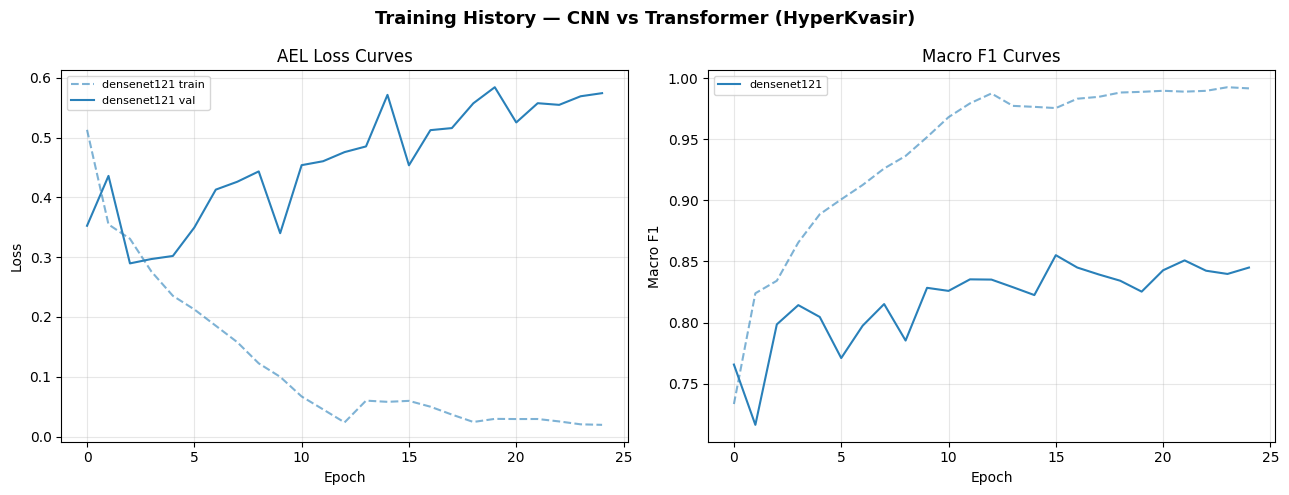

DenseNet-121 done.


In [17]:
# ── MODEL 1 / 3 : DenseNet-121 ───────────────────────────────────────────────
# Checkpoint: checkpoints/densenet121/best.pt
# If interrupted, re-run this cell — it will load the saved checkpoint automatically.
trained_models['densenet121'], histories['densenet121'] = \
    run_training(build_densenet121(), train_ldr, val_ldr, 'densenet121')
plot_training_curves(histories)   # auto-save training_curves.png
print('DenseNet-121 done.')

[DONE] efficientnet_b0 already completed 25/25 epochs.


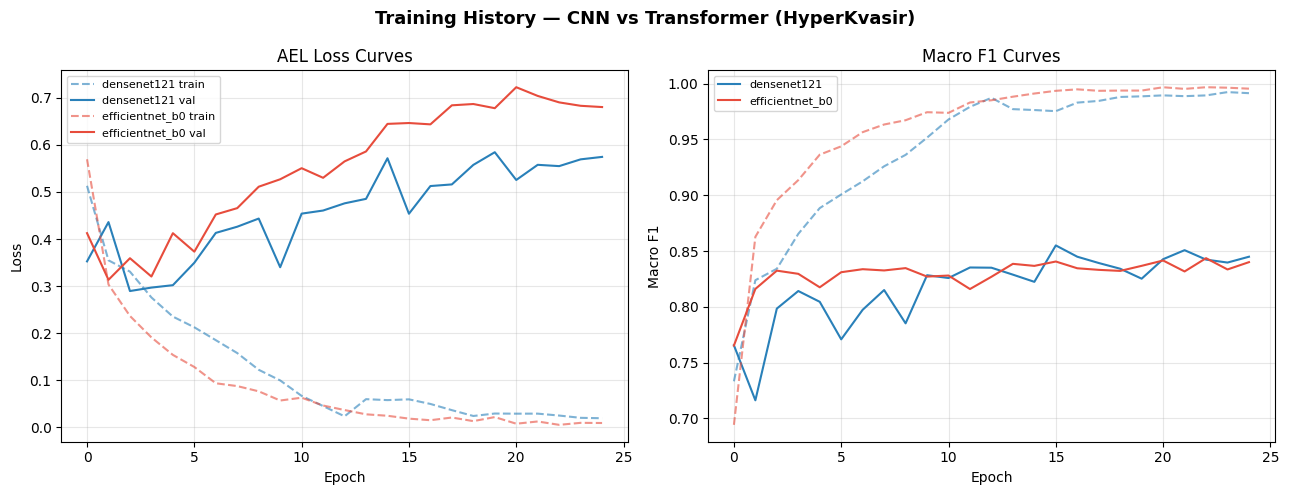

EfficientNet-B0 done.


In [18]:
# ── MODEL 2 / 3 : EfficientNet-B0 ───────────────────────────────────────────
trained_models['efficientnet_b0'], histories['efficientnet_b0'] = \
    run_training(build_efficientnet_b0(), train_ldr, val_ldr, 'efficientnet_b0')
plot_training_curves(histories)   # auto-save training_curves.png
print('EfficientNet-B0 done.')

[DONE] deit_tiny already completed 25/25 epochs.


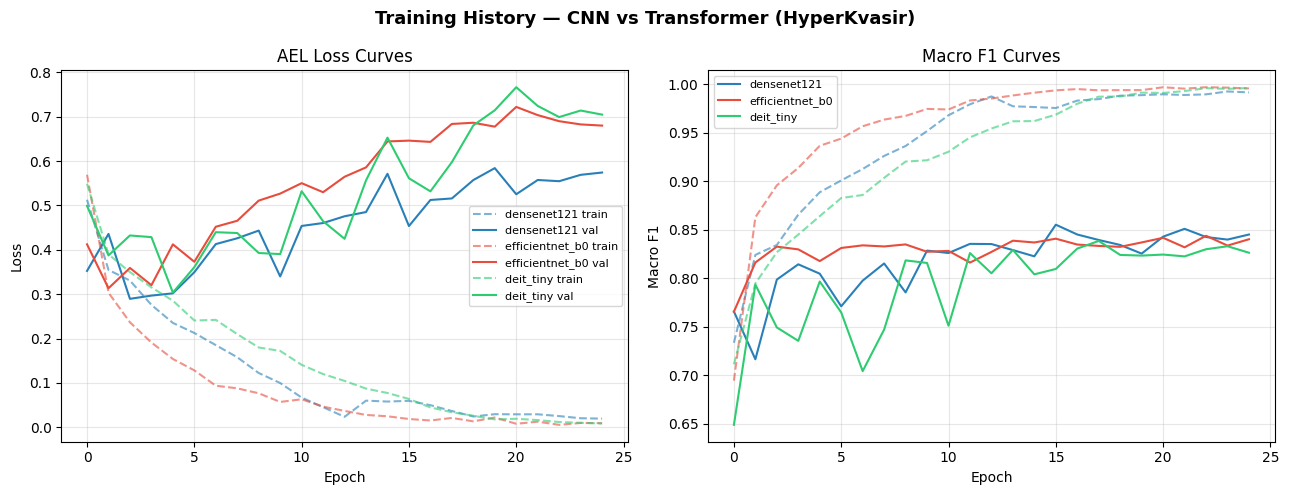

DeiT-Tiny done.


In [19]:
# ── MODEL 3 / 3 : DeiT-Tiny ──────────────────────────────────────────────────
trained_models['deit_tiny'], histories['deit_tiny'] = \
    run_training(build_deit_tiny(), train_ldr, val_ldr, 'deit_tiny')
plot_training_curves(histories)   # auto-save training_curves.png
print('DeiT-Tiny done.')

Models trained so far: ['densenet121', 'efficientnet_b0', 'deit_tiny']


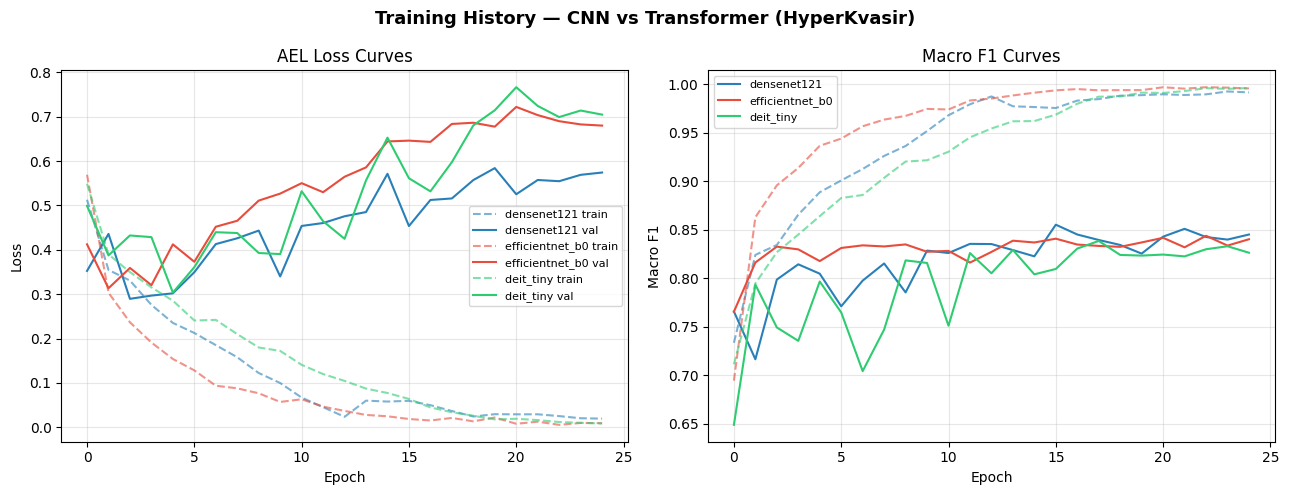

In [20]:
# ── PLOT TRAINING CURVES (run after all 4 models complete) ──────────────────
print(f'Models trained so far: {list(trained_models.keys())}')
if histories:
    plot_training_curves(histories)

## 7. AEL Ablation Study
Compare Asymmetric Endoscopy Loss vs Cross-Entropy vs Focal Loss on DenseNet-121.

In [21]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def run_ablation(train_ldr, val_ldr, test_ldr, epochs=25,
                 progress_path=None):
    """Train 3 loss variants on DenseNet-121.
    Saves one JSON entry per variant so a crash only costs the current variant.
    """
    import json as _j, os as _o

    # Load any already-finished variants
    done = {}
    if progress_path and _o.path.exists(progress_path):
        done = _j.load(open(progress_path))
        print(f'[RESUME] Quick ablation: {list(done.keys())} already done.', flush=True)

    loss_fns = {
        'Cross-Entropy': nn.CrossEntropyLoss(),
        'Focal (γ=2)':   FocalLoss(gamma=2.0),
        'AEL (Ours)':    AsymmetricEndoscopyLoss(),
    }
    results = dict(done)

    for name, loss_fn in loss_fns.items():
        if name in done:
            print(f'  [SKIP] {name} already done.', flush=True)
            continue
        print(f'\n>>> Ablation: {name}', flush=True)
        model = build_densenet121().to(DEVICE)
        opt   = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
        sch   = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
        for epoch in range(1, epochs + 1):
            model.train()
            running_loss = 0.0
            batch_bar = tqdm(train_ldr, desc=f'{name} Ep{epoch}/{epochs}',
                             unit='batch', leave=False)
            for imgs, labels in batch_bar:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt.zero_grad()
                loss = loss_fn(model(imgs), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                running_loss += loss.item()
                batch_bar.set_postfix(loss=f'{loss.item():.4f}')
            sch.step()
            print(f'  Ep {epoch}/{epochs} — avg loss: {running_loss / len(train_ldr):.4f}', flush=True)

        model.eval()
        preds_all, trues_all = [], []
        with torch.no_grad():
            for imgs, labels in tqdm(test_ldr, desc=f'  {name} eval', leave=False):
                preds_all.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
                trues_all.extend(labels.numpy())
        macro_f1         = f1_score(trues_all, preds_all, average='macro', zero_division=0)
        high_risk_recall = recall_score(
            [1 if t == 3 else 0 for t in trues_all],
            [1 if p == 3 else 0 for p in preds_all], zero_division=0)
        results[name] = {'macro_f1': macro_f1, 'high_risk_recall': high_risk_recall}
        print(f'  Done — Macro F1={macro_f1:.4f}  High-Risk Recall={high_risk_recall:.4f}', flush=True)

        # Atomic save after each variant so a crash costs at most one variant
        if progress_path:
            _tmp = progress_path + '.tmp'
            with open(_tmp, 'w') as _f:
                _j.dump(results, _f, indent=2)
            _o.replace(_tmp, progress_path)

    print('\nAblation Summary:', flush=True)
    print(f'{"Loss":<20} {"Macro F1":>10} {"High-Risk Recall":>18}', flush=True)
    print('-' * 50)
    for k, v in results.items():
        print(f'{k:<20} {v["macro_f1"]:>10.4f} {v["high_risk_recall"]:>18.4f}', flush=True)
    return results


print('Ablation ready. Call: ablation_results = run_ablation(train_ldr, val_ldr, test_ldr)', flush=True)


Ablation ready. Call: ablation_results = run_ablation(train_ldr, val_ldr, test_ldr)


[RESUME] Quick ablation: ['Cross-Entropy', 'Focal (γ=2)', 'AEL (Ours)'] already done.
  [SKIP] Cross-Entropy already done.
  [SKIP] Focal (γ=2) already done.
  [SKIP] AEL (Ours) already done.

Ablation Summary:
Loss                   Macro F1   High-Risk Recall
--------------------------------------------------
Cross-Entropy            0.8495             0.9536
Focal (γ=2)              0.8322             0.9567
AEL (Ours)               0.8332             0.9505
Saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\checkpoints\ablation_results.json


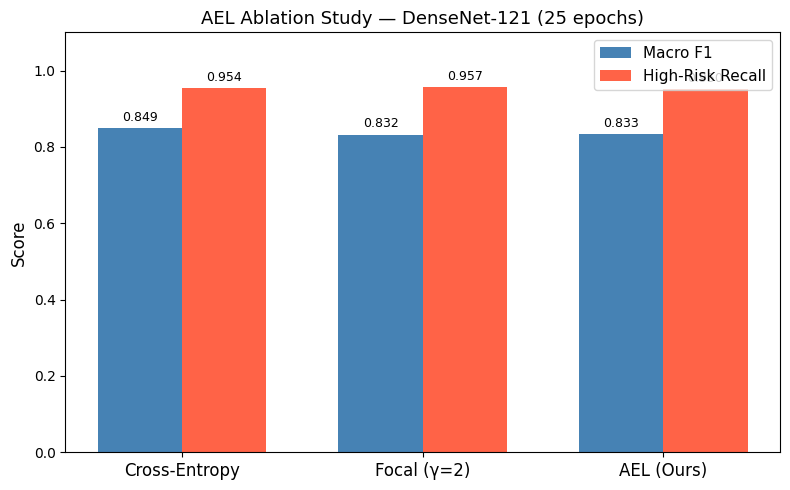

Saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\ablation_study.png

=== LaTeX rows for tab:ablation ===
Cross-Entropy (uniform) & 0.8495 & 0.9536\\
Focal Loss ($\gamma=2$) & 0.8322 & 0.9567\\
AEL $[1.0, 3.5, 3.0, 5.0]$ (Ours) & 0.8332 & 0.9505\\


In [22]:
# ── RUN ABLATION STUDY (≈ 75 min on M2 — 3 × 25 epochs) ──────────────────
# Requires: train_ldr, val_ldr, test_ldr  (run Sections 2-3 first)
import json as _json, os as _os
import matplotlib.pyplot as plt
import numpy as np

_abl_prog = _os.path.join(CKPT_DIR, 'ablation_quick_progress.json')
ablation_results = run_ablation(train_ldr, val_ldr, test_ldr, epochs=25,
                                progress_path=_abl_prog)

# ── Save final JSON for reproducibility ───────────────────────────────────
_abl_path = _os.path.join(CKPT_DIR, 'ablation_results.json')
with open(_abl_path, 'w') as _f:
    _json.dump(ablation_results, _f, indent=2)
print(f'Saved → {_abl_path}')

# ── Bar chart ──────────────────────────────────────────────────────────────
_names  = list(ablation_results.keys())
_f1s    = [ablation_results[k]['macro_f1']        for k in _names]
_hr_rec = [ablation_results[k]['high_risk_recall'] for k in _names]

_x  = np.arange(len(_names))
_w  = 0.35
_fig, _ax = plt.subplots(figsize=(8, 5))
_b1 = _ax.bar(_x - _w/2, _f1s,    _w, label='Macro F1',         color='steelblue')
_b2 = _ax.bar(_x + _w/2, _hr_rec, _w, label='High-Risk Recall', color='tomato')
_ax.set_xticks(_x)
_ax.set_xticklabels(_names, fontsize=12)
_ax.set_ylim(0, 1.10)
_ax.set_ylabel('Score', fontsize=12)
_ax.set_title('AEL Ablation Study — DenseNet-121 (25 epochs)', fontsize=13)
_ax.legend(fontsize=11)
_ax.bar_label(_b1, fmt='%.3f', padding=3, fontsize=9)
_ax.bar_label(_b2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
_png = _os.path.join(PROJECT_DIR, 'ablation_study.png')
plt.savefig(_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {_png}')

# ── Print LaTeX rows to paste into paper.tex ──────────────────────────────
print('\n=== LaTeX rows for tab:ablation ===')
_label_map = {
    'AEL (Ours)':    r'AEL $[1.0, 3.5, 3.0, 5.0]$ (Ours)',
    'Cross-Entropy': r'Cross-Entropy (uniform)',
    'Focal (\u03b3=2)': r'Focal Loss ($\gamma=2$)',
}
for k, v in ablation_results.items():
    label = _label_map.get(k, k)
    print(f'{label} & {v["macro_f1"]:.4f} & {v["high_risk_recall"]:.4f}\\\\')


## 8. Cross-Dataset Evaluation — Kvasir-v2
Train on HyperKvasir, evaluate zero-shot on Kvasir-v2.
Kvasir-v2 folder structure: data/Kvasir-v2/<class-name>/<images>


In [23]:
KVASIR_V2_MAP = {
    'esophagitis':        1,   # Inflammatory
    'ulcerative-colitis': 2,   # Pre-malignant (Kvasir-v2 has mixed severity)
    'polyps':             2,   # Pre-malignant
    'barretts':           2,   # Pre-malignant
    'normal-cecum':       0,
    'normal-pylorus':     0,
    'normal-z-line':      0,
    'dyed-lifted-polyps': 3,   # High-Risk
    'dyed-resection-margins': 3,
}


def load_kvasir_v2(data_dir: str) -> pd.DataFrame:
    rows = []
    if not os.path.exists(data_dir):
        print(f'[!] Kvasir-v2 not found at {data_dir}')
        print('    Download from: https://datasets.simula.no/kvasir/')
        return pd.DataFrame()
    for class_folder in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_folder)
        if not os.path.isdir(class_dir): continue
        label = KVASIR_V2_MAP.get(class_folder)
        if label is None: continue
        for f in os.listdir(class_dir):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')): continue
            rows.append({'image_path': os.path.join(class_dir, f),
                         'label': label, 'label_name': LABEL_NAMES[label],
                         'source_class': class_folder})
    df = pd.DataFrame(rows)
    if len(df):
        print(f'Kvasir-v2: {len(df)} images')
        print(df['label_name'].value_counts().to_string())
    return df


EVAL_CACHE_DIR = os.path.join(PROJECT_DIR, 'checkpoints', 'eval_cache')
os.makedirs(EVAL_CACHE_DIR, exist_ok=True)


def _eval_cache_path(dataset_name):
    return os.path.join(EVAL_CACHE_DIR, dataset_name.replace(' ', '_').replace('/', '_') + '.npz')


@torch.no_grad()
def evaluate_detailed(model, loader, device, dataset_name=''):
    _np_   = _eval_cache_path(dataset_name)
    _name  = dataset_name.split()[0]                                   # e.g. 'densenet121'
    _ckpt  = os.path.join(CKPT_DIR, _name, 'best.pt')
    _mtime = os.path.getmtime(_ckpt) if os.path.exists(_ckpt) else None

    preds_all = trues_all = probs_all = None
    if _mtime is not None and os.path.exists(_np_):
        _d = np.load(_np_, allow_pickle=True)
        if _d['ckpt_mtime'].item() == _mtime:                          # invalidate if model retrained
            preds_all, trues_all, probs_all = _d['preds'], _d['trues'], _d['probs']
            print(f'[CACHE] {dataset_name}: loaded {len(preds_all)} preds \u2192 {_np_}')

    if preds_all is None:                                              # fresh forward pass
        model.eval()
        _p, _t, _pb = [], [], []
        for imgs, labels in tqdm(loader, desc=f'Evaluating {dataset_name}', leave=True):
            out = model(imgs.to(device))
            _pb.extend(F.softmax(out, dim=1).cpu().numpy())
            _p.extend(out.argmax(1).cpu().numpy())
            _t.extend(labels.numpy())
        preds_all, trues_all, probs_all = (np.array(_p), np.array(_t), np.array(_pb))
        if _mtime is not None:                                         # only cache when ckpt mtime known
            np.savez(_np_, preds=preds_all, trues=trues_all, probs=probs_all, ckpt_mtime=_mtime)
            print(f'[CACHE] {dataset_name}: saved \u2192 {_np_}')

    macro_f1     = f1_score(trues_all, preds_all, average='macro', zero_division=0)
    per_class    = f1_score(trues_all, preds_all, average=None,    zero_division=0)
    high_risk_recall = recall_score(
        [1 if t == 3 else 0 for t in trues_all],
        [1 if p == 3 else 0 for p in preds_all], zero_division=0)
    print(f'\n{"="*60}')
    print(f'Dataset: {dataset_name}  |  Macro F1: {macro_f1:.4f}  |  High-Risk Recall: {high_risk_recall:.4f}')
    print(classification_report(trues_all, preds_all, target_names=LABEL_NAMES, zero_division=0))
    return {'macro_f1': macro_f1, 'per_class': per_class,
            'high_risk_recall': high_risk_recall,
            'preds': preds_all, 'trues': trues_all,
            'probs': probs_all}


def plot_confusion_matrix(results, model_name):
    cm = confusion_matrix(results['trues'], results['preds'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    short = ['Normal', 'Inflam.', 'Pre-mal.', 'High-Risk']
    for ax, data, fmt, title in zip([ax1, ax2],
                                     [cm, cm.astype(float) / cm.sum(axis=1, keepdims=True)],
                                     ['d', '.1%'],
                                     ['Count', 'Normalized']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=short, yticklabels=short)
        ax.set(xlabel='Predicted', ylabel='True',
               title=f'{model_name} Confusion Matrix ({title})')
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'confusion_matrix_{model_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()


print('Cross-dataset evaluation ready.')


Cross-dataset evaluation ready.



--- densenet121 ---
[CACHE] densenet121 (HyperKvasir test): loaded 1145 preds → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\checkpoints\eval_cache\densenet121_(HyperKvasir_test).npz

Dataset: densenet121 (HyperKvasir test)  |  Macro F1: 0.8419  |  High-Risk Recall: 0.9659
               precision    recall  f1-score   support

       Normal       0.96      0.94      0.95       450
 Inflammatory       0.58      0.58      0.58        97
Pre_malignant       0.84      0.89      0.86       275
    High_Risk       0.99      0.97      0.98       323

     accuracy                           0.90      1145
    macro avg       0.84      0.84      0.84      1145
 weighted avg       0.91      0.90      0.91      1145



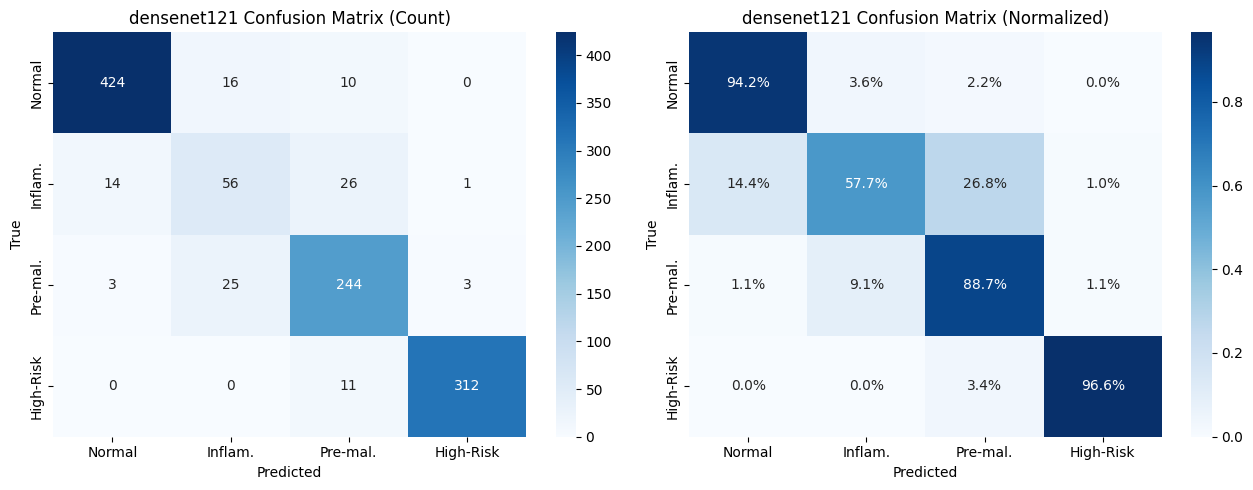


--- efficientnet_b0 ---
[CACHE] efficientnet_b0 (HyperKvasir test): loaded 1145 preds → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\checkpoints\eval_cache\efficientnet_b0_(HyperKvasir_test).npz

Dataset: efficientnet_b0 (HyperKvasir test)  |  Macro F1: 0.8390  |  High-Risk Recall: 0.9659
               precision    recall  f1-score   support

       Normal       0.94      0.96      0.95       450
 Inflammatory       0.61      0.53      0.56        97
Pre_malignant       0.85      0.88      0.87       275
    High_Risk       0.99      0.97      0.98       323

     accuracy                           0.91      1145
    macro avg       0.85      0.83      0.84      1145
 weighted avg       0.90      0.91      0.90      1145



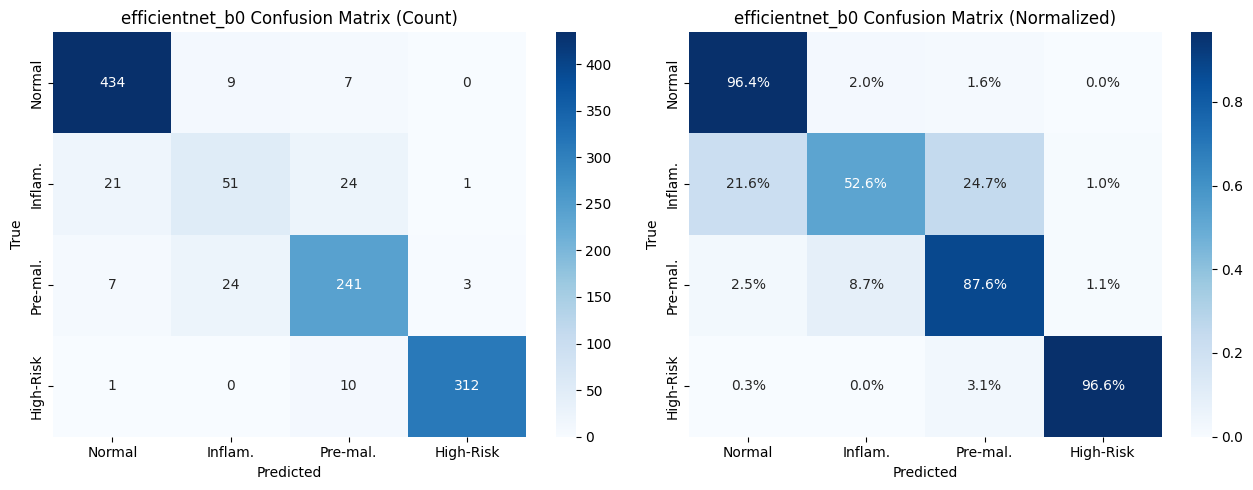


--- deit_tiny ---
[CACHE] deit_tiny (HyperKvasir test): loaded 1145 preds → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\checkpoints\eval_cache\deit_tiny_(HyperKvasir_test).npz

Dataset: deit_tiny (HyperKvasir test)  |  Macro F1: 0.8106  |  High-Risk Recall: 0.9505
               precision    recall  f1-score   support

       Normal       0.95      0.95      0.95       450
 Inflammatory       0.54      0.45      0.49        97
Pre_malignant       0.79      0.87      0.83       275
    High_Risk       0.99      0.95      0.97       323

     accuracy                           0.89      1145
    macro avg       0.82      0.81      0.81      1145
 weighted avg       0.89      0.89      0.89      1145



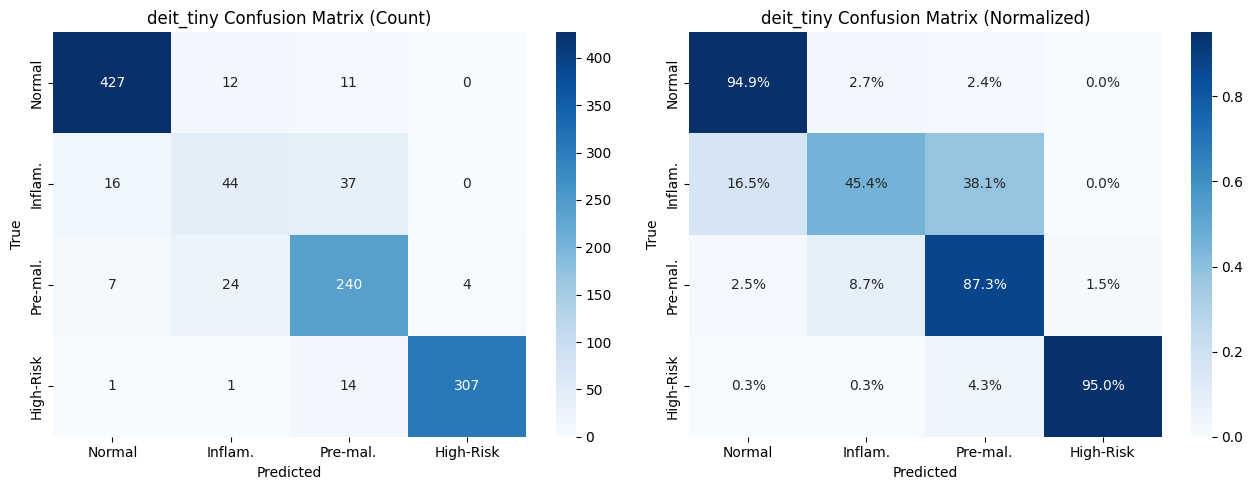

Kvasir-v2: 8000 images
label_name
Normal           3000
High_Risk        2000
Pre_malignant    2000
Inflammatory     1000

--- densenet121 on Kvasir-v2 ---
[CACHE] densenet121 (Kvasir-v2): loaded 8000 preds → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\checkpoints\eval_cache\densenet121_(Kvasir-v2).npz

Dataset: densenet121 (Kvasir-v2)  |  Macro F1: 0.7403  |  High-Risk Recall: 0.9715
               precision    recall  f1-score   support

       Normal       0.97      0.63      0.76      3000
 Inflammatory       0.62      0.46      0.53      1000
Pre_malignant       0.56      0.94      0.70      2000
    High_Risk       0.97      0.97      0.97      2000

     accuracy                           0.77      8000
    macro avg       0.78      0.75      0.74      8000
 weighted avg       0.82      0.77      0.77      8000


--- efficientnet_b0 on Kvasir-v2 ---
[CACHE] efficientnet_b0 (Kvasir-v2): loaded 8000 preds → D:\Research paper code run\gas\GastroEndoscopy-Risk

In [24]:
# ── RUN EVALUATION (test set + Kvasir-v2) ────────────────────────────────────
criterion  = AsymmetricEndoscopyLoss()
results    = {}

for name, model in trained_models.items():
    print(f'\n--- {name} ---')
    results[name] = evaluate_detailed(model, test_ldr, DEVICE,
                                      dataset_name=f'{name} (HyperKvasir test)')
    plot_confusion_matrix(results[name], name)

# Cross-dataset on Kvasir-v2
kv2_df = load_kvasir_v2('data/Kvasir-v2')
ext_results = {}
if len(kv2_df) > 0:
    kv2_ldr = DataLoader(EndoscopyDataset(kv2_df, val_transforms),
                         BATCH_SIZE, shuffle=False, num_workers=0)
    ext_results['Kvasir-v2'] = {}
    for name, model in trained_models.items():
        print(f'\n--- {name} on Kvasir-v2 ---')
        ext_results['Kvasir-v2'][name] = evaluate_detailed(
            model, kv2_ldr, DEVICE,
            dataset_name=f'{name} (Kvasir-v2)')

print('Evaluation complete. Run Section 9 for ROC curves, Section 14 for paper tables.')

# ── Save main HyperKvasir results to CSV ──────────────────────────────────
import pandas as _pd_eval
_main_rows = []
for _name, _res in results.items():
    _main_rows.append({
        'model':            _name,
        'macro_f1':         round(_res['macro_f1'], 6),
        'high_risk_recall': round(_res['high_risk_recall'], 6),
        'normal_f1':        round(float(_res['per_class'][0]), 6),
        'inflammatory_f1':  round(float(_res['per_class'][1]), 6),
        'premalignant_f1':  round(float(_res['per_class'][2]), 6),
        'highrisk_f1':      round(float(_res['per_class'][3]), 6),
    })
_main_csv = os.path.join(PROJECT_DIR, 'main_results.csv')
_pd_eval.DataFrame(_main_rows).to_csv(_main_csv, index=False)
print(f'Saved \u2192 {_main_csv}')

# ── Save Kvasir-v2 cross-dataset results to CSV ────────────────────────────
if ext_results:
    _kv2_rows = []
    for _name in results:
        _kv2 = ext_results.get('Kvasir-v2', {}).get(_name, {})
        if _kv2:
            _kv2_rows.append({
                'model':            _name,
                'hk_macro_f1':      round(results[_name]['macro_f1'], 6),
                'kv2_macro_f1':     round(_kv2['macro_f1'], 6),
                'f1_drop':          round(results[_name]['macro_f1'] - _kv2['macro_f1'], 6),
                'kv2_hr_recall':    round(_kv2['high_risk_recall'], 6),
            })
    _kv2_csv = os.path.join(PROJECT_DIR, 'kv2_results.csv')
    _pd_eval.DataFrame(_kv2_rows).to_csv(_kv2_csv, index=False)
    print(f'Saved \u2192 {_kv2_csv}')


## 9. ROC-AUC Curves — Per Class (One-vs-Rest)

ROC-AUC analysis ready.


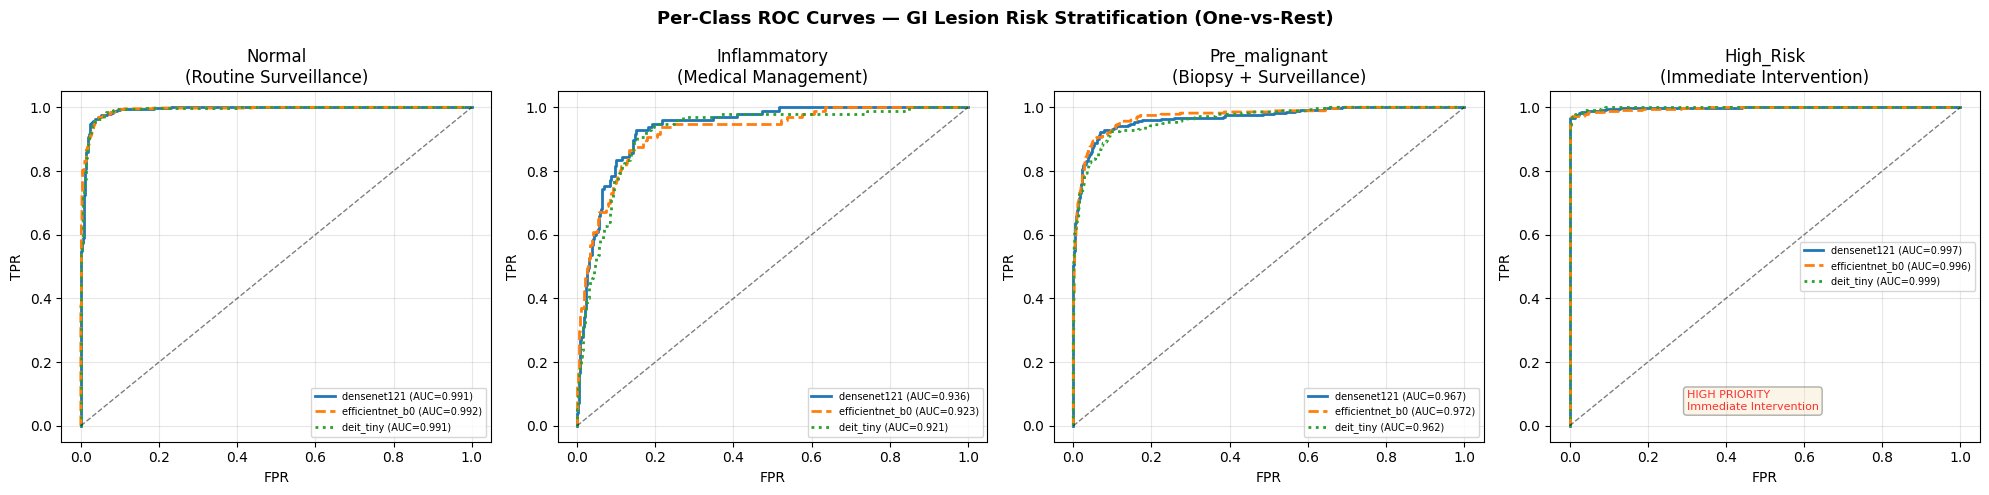


Model                           Normal    Inflammatory   Pre_malignant       High_Risk   Macro AUC
------------------------------------------------------------------------------------------
densenet121                     0.9913          0.9362          0.9675          0.9972      0.9730
efficientnet_b0                 0.9919          0.9234          0.9720          0.9962      0.9709
deit_tiny                       0.9914          0.9213          0.9623          0.9985      0.9684
AUC results saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\auc_results.csv


In [25]:
def plot_roc_curves(results_dict: dict):
    n_cls   = NUM_CLASSES
    colors  = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    styles  = ['-', '--', ':', '-.']
    fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 5))

    for c, (cls_name, risk, ax) in enumerate(zip(LABEL_NAMES, RISK_LABELS, axes)):
        for (model_name, results), ls in zip(results_dict.items(), styles):
            trues_bin = [1 if t == c else 0 for t in results['trues']]
            probs_cls = np.array(results['probs'])[:, c]
            fpr, tpr, _ = roc_curve(trues_bin, probs_cls)
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, linestyle=ls, linewidth=2,
                    label=f'{model_name} (AUC={roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
        ax.set(xlabel='FPR', ylabel='TPR',
               title=f'{cls_name}\n({risk})')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        if c == 3:
            ax.text(0.3, 0.05, 'HIGH PRIORITY\nImmediate Intervention',
                    fontsize=8, color='red', alpha=0.8,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('Per-Class ROC Curves — GI Lesion Risk Stratification (One-vs-Rest)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()


def print_auc_table(results_dict: dict):
    print(f'\n{"Model":<22}', end='')
    for c in LABEL_NAMES: print(f'{c:>16}', end='')
    print(f'{"Macro AUC":>12}')
    print('-' * 90)
    for model_name, results in results_dict.items():
        trues_bin = label_binarize(results['trues'], classes=list(range(NUM_CLASSES)))
        aucs = []
        print(f'{model_name:<22}', end='')
        for c in range(NUM_CLASSES):
            a = roc_auc_score(trues_bin[:, c], np.array(results['probs'])[:, c])
            aucs.append(a)
            print(f'{a:>16.4f}', end='')
        print(f'{np.mean(aucs):>12.4f}')


print('ROC-AUC analysis ready.')


# ── Run ROC analysis (requires Section 8 evaluation to have run first) ──────
if 'results' in globals() and results:
    plot_roc_curves(results)
    print_auc_table(results)
else:
    print('[!] Run Section 8 evaluation first.')

# ── Save AUC results to CSV ────────────────────────────────────────────────
if 'results' in globals() and results:
    import pandas as _pd_auc
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_auc_score
    _auc_rows = []
    for _name, _res in results.items():
        _tb = label_binarize(_res['trues'], classes=list(range(NUM_CLASSES)))
        _aucs = [roc_auc_score(_tb[:, c], np.array(_res['probs'])[:, c]) for c in range(NUM_CLASSES)]
        _auc_rows.append({
            'model':           _name,
            'auc_normal':      round(_aucs[0], 6),
            'auc_inflammatory':round(_aucs[1], 6),
            'auc_premalignant':round(_aucs[2], 6),
            'auc_highrisk':    round(_aucs[3], 6),
            'macro_auc':       round(float(np.mean(_aucs)), 6),
        })
    _auc_csv = os.path.join(PROJECT_DIR, 'auc_results.csv')
    _pd_auc.DataFrame(_auc_rows).to_csv(_auc_csv, index=False)
    print(f'AUC results saved \u2192 {_auc_csv}')


## 10. GradCAM Explainability
Localizes mucosal irregularities, pit patterns, and vascular changes
that drive each risk-tier classification decision.


In [26]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = None
        self.acts  = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'acts', o.detach()))
        # register_full_backward_hook is the non-deprecated API (PyTorch ≥ 2.0)
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img = img_tensor.unsqueeze(0).to(DEVICE)
        out = self.model(img)
        if class_idx is None:
            class_idx = out.argmax().item()
        self.model.zero_grad()
        out[0, class_idx].backward()

        if self.grads.dim() == 4:
            # CNN: (B, C, H, W)
            weights = self.grads.mean(dim=[2, 3], keepdim=True)
            cam     = F.relu((weights * self.acts).sum(1, keepdim=True))
            cam     = cam.squeeze().cpu().numpy()
        else:
            # Transformer: (B, N, C) — reshape token sequence to 2-D spatial grid
            weights = self.grads.mean(dim=1)                              # (B, C)
            cam     = F.relu((weights.unsqueeze(1) * self.acts).sum(-1))  # (B, N)
            cam     = cam.squeeze().cpu().numpy()
            n       = int(cam.shape[0] ** 0.5)
            cam     = cam[:n * n].reshape(n, n)

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam, class_idx


def get_target_layer(model, model_name):
    if model_name == 'densenet121':
        return model.features.denseblock4.denselayer16.conv2
    elif model_name == 'efficientnet_b0':
        return model.conv_head        # last 1×1 conv before global pool
    elif model_name == 'deit_tiny':
        return model.blocks[-1].norm1 # final transformer block layer norm
    raise ValueError(f'Unknown model: {model_name}')


def visualize_gradcam(model, model_name, image_paths, true_labels=None):
    target_layer = get_target_layer(model, model_name)
    gcam = GradCAM(model, target_layer)
    inv  = transforms.Normalize(
        mean=[-m / s for m, s in zip(DATASET_MEAN, DATASET_STD)],
        std=[1 / s for s in DATASET_STD])

    n      = len(image_paths)
    colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 9))
    axes = axes.reshape(2, n)   # always 2-D, regardless of n

    for i, path in enumerate(image_paths):
        img_t     = val_transforms(Image.open(path).convert('RGB'))
        cam, pred = gcam.generate(img_t)
        img_np    = np.array(inv(img_t).permute(1, 2, 0).clamp(0, 1))
        heatmap   = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB) / 255.0
        overlay   = np.clip(0.6 * img_np + 0.4 * heatmap, 0, 1)

        gt = LABEL_NAMES[true_labels[i]] if true_labels else ''
        axes[0, i].imshow(img_np);  axes[0, i].set_title(f'GT: {gt}', fontsize=10)
        axes[1, i].imshow(overlay); axes[1, i].set_title(
            f'{LABEL_NAMES[pred]}\n{RISK_LABELS[pred]}',
            fontsize=9, color=colors[pred])
        for ax in [axes[0, i], axes[1, i]]:
            ax.axis('off')

    plt.suptitle(f'GradCAM — {model_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(
        os.path.dirname(os.path.abspath('GastroEndoscopy_Risk_Stratification.ipynb')),
        f'gradcam_{model_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()

print('GradCAM ready.')

GradCAM ready.


In [27]:
import os

# ── RUN GRADCAM — one image per risk class, all trained models ────────────────
SAVE_DIR = os.path.dirname(os.path.abspath('GastroEndoscopy_Risk_Stratification.ipynb'))

# Pick one representative test image per class
sample_paths, sample_labels = [], []
for label in range(NUM_CLASSES):
    rows = test_df[test_df['label'] == label]
    if len(rows) == 0:
        continue
    row = rows.iloc[0]
    sample_paths.append(row['image_path'])
    sample_labels.append(label)

print(f'Generating GradCAM for {len(sample_paths)} classes...')

import matplotlib
matplotlib.use('Agg')          # save to file without needing a display
import matplotlib.pyplot as plt

for name, model in trained_models.items():
    out_path = os.path.join(SAVE_DIR, f'gradcam_{name}.png')
    visualize_gradcam(model, name, sample_paths, true_labels=sample_labels)
    # rename if saved with relative path
    if os.path.exists(f'gradcam_{name}.png') and not os.path.exists(out_path):
        os.rename(f'gradcam_{name}.png', out_path)
    print(f'  Saved → {out_path}')

print('Done. PNG files saved in project folder.')

Generating GradCAM for 4 classes...
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\gradcam_densenet121.png
  Saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\gradcam_densenet121.png
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\gradcam_efficientnet_b0.png
  Saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\gradcam_efficientnet_b0.png
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\gradcam_deit_tiny.png
  Saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\gradcam_deit_tiny.png
Done. PNG files saved in project folder.


## 11. Monte Carlo Dropout Uncertainty
Flags borderline lesions for mandatory endoscopist review.

In [28]:
def mc_predict(model, img_tensor, n_samples=30):
    """Monte Carlo Dropout inference. Runs n_samples stochastic forward passes."""
    model.eval()
    # Enable only Dropout layers for MC sampling
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

    img   = img_tensor.unsqueeze(0).to(DEVICE)
    probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            probs.append(F.softmax(model(img), dim=1).cpu().numpy())

    # Restore full eval mode
    model.eval()

    probs      = np.stack(probs).squeeze(1)          # (n_samples, NUM_CLASSES)
    mean_probs = probs.mean(axis=0)
    pred       = int(mean_probs.argmax())
    confidence = float(mean_probs.max())
    entropy    = float(-np.sum(mean_probs * np.log(mean_probs + 1e-8)))
    flag       = confidence < 0.75 or pred >= 2      # Pre-malignant or High-Risk always flagged

    return {
        'prediction':  pred,
        'label':       LABEL_NAMES[pred],
        'risk':        RISK_LABELS[pred],
        'confidence':  confidence,
        'uncertainty': entropy,
        'flag':        flag,
        'mean_probs':  mean_probs,
    }


print('MC Dropout ready.')
print('Flag rule: confidence < 0.75  OR  predicted class ≥ Pre-malignant')

MC Dropout ready.
Flag rule: confidence < 0.75  OR  predicted class ≥ Pre-malignant


## 12. Endoscopist Workload Simulation
Quantifies AI burden reduction while maintaining zero missed High-Risk lesions.

In [29]:
WL_CACHE_DIR = os.path.join(PROJECT_DIR, 'checkpoints', 'workload_cache')
os.makedirs(WL_CACHE_DIR, exist_ok=True)


def endoscopist_simulation(model, test_df, confidence_threshold=0.75, model_name=None):
    auto_cleared, flagged = 0, 0
    missed_high_risk = 0
    flag_breakdown = {'low_confidence': 0, 'pre_malignant': 0, 'high_risk': 0}

    # MC results (cacheable — 30 stochastic dropout passes per image)
    mc_results = None
    _cache = None
    if model_name:
        _ckpt = os.path.join(CKPT_DIR, model_name, 'best.pt')
        _mt   = os.path.getmtime(_ckpt) if os.path.exists(_ckpt) else None
        if _mt is not None:
            _cache = os.path.join(WL_CACHE_DIR, f'{model_name}_n{len(test_df)}_m{int(_mt)}.npy')
            if os.path.exists(_cache):
                _arr = np.load(_cache)
                mc_results = [(int(r[0]), float(r[1]), int(r[2])) for r in _arr]
                print(f'[CACHE] workload MC results loaded ({len(mc_results)} imgs) \u2192 {_cache}')

    if mc_results is None:
        mc_results = []
        for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Simulating'):
            img = val_transforms(Image.open(row['image_path']).convert('RGB'))
            res = mc_predict(model, img)
            mc_results.append((res['prediction'], res['confidence'], int(row['label'])))
        if _cache:
            np.save(_cache, np.array(mc_results))
            print(f'[CACHE] workload MC results saved \u2192 {_cache}')

    # Apply the caller-supplied threshold (not mc_predict's hardcoded 0.75)
    for pred, conf, true_label in mc_results:
        auto = conf >= confidence_threshold and pred < 2
        if not auto:
            flagged += 1
            if conf < confidence_threshold: flag_breakdown['low_confidence'] += 1
            if pred == 2:                    flag_breakdown['pre_malignant']  += 1
            if pred == 3:                    flag_breakdown['high_risk']      += 1
        else:
            auto_cleared += 1
            if true_label == 3:
                missed_high_risk += 1

    total = len(test_df)
    print(f'\nEndoscopist Workload Simulation  (threshold={confidence_threshold})')
    print(f'  Total patients:              {total}')
    print(f'  AI auto-cleared:             {auto_cleared} ({100*auto_cleared/total:.1f}%)')
    print(f'  Flagged for endoscopist:     {flagged} ({100*flagged/total:.1f}%)')
    print(f'  Workload reduction:          {100*auto_cleared/total:.1f}%')
    print(f'  Missed High-Risk lesions:    {missed_high_risk}  (target: 0)')
    print(f'  Flag breakdown: {flag_breakdown}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    ax1.pie([auto_cleared, flagged],
            labels=[f'AI auto-cleared\n({100*auto_cleared/total:.1f}%)',
                    f'Endoscopist review\n({100*flagged/total:.1f}%)'],
            colors=['#2ECC71', '#E74C3C'], autopct='%1.1f%%', startangle=90)
    ax1.set_title('Endoscopy Screening Workflow\nAI Workload Distribution')

    # Threshold sweep over precomputed mc_results — no redundant forward passes
    thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    reductions = []
    for thresh in thresholds:
        cleared = sum(1 for pred, conf, _ in mc_results
                      if conf >= thresh and pred < 2)
        reductions.append(100 * cleared / total)
    ax2.plot(thresholds, reductions, 'b-o', linewidth=2)
    ax2.axvline(confidence_threshold, color='red', linestyle='--',
                label=f'Selected threshold={confidence_threshold}')
    ax2.set(xlabel='Confidence Threshold', ylabel='Workload Reduction (%)',
            title='Threshold vs. Endoscopist Burden Reduction')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'workload_simulation.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return auto_cleared, flagged, missed_high_risk


print('Simulation ready.')

Simulation ready.


In [30]:
# ── RUN ENDOSCOPIST WORKLOAD SIMULATION ───────────────────────────────────────
if 'results' not in globals() or not results:
    raise RuntimeError('Run Section 8 evaluation first — results dict is missing.')
best_model_name = max(trained_models.keys(),
    key=lambda n: results[n]['macro_f1'] if n in results else 0)
best_model = trained_models[best_model_name]
print(f'Running simulation with best model: {best_model_name}')
auto_cleared, flagged, missed = endoscopist_simulation(
    best_model, test_df, confidence_threshold=0.75,
    model_name=best_model_name)
print(f'PNG saved → {os.path.join(PROJECT_DIR, "workload_simulation.png")}')

# ── Save workload results to JSON and CSV ─────────────────────────────────
import json as _json_wl, pandas as _pd_wl
_total = len(test_df)
_workload_data = {
    'model':             best_model_name,
    'total':             _total,
    'auto_cleared':      int(auto_cleared),
    'flagged':           int(flagged),
    'missed_high_risk':  int(missed),
    'pct_auto_cleared':  round(100 * auto_cleared / _total, 1),
    'pct_flagged':       round(100 * flagged / _total, 1),
    'threshold':         0.75,
    'mc_passes':         30,
}
_wl_json = os.path.join(PROJECT_DIR, 'workload_results.json')
with open(_wl_json, 'w') as _f:
    _json_wl.dump(_workload_data, _f, indent=2)
_wl_csv = os.path.join(PROJECT_DIR, 'workload_results.csv')
_pd_wl.DataFrame([_workload_data]).to_csv(_wl_csv, index=False)
print(f'Workload results saved \u2192 {_wl_json}')
print(f'Workload results saved \u2192 {_wl_csv}')
print(f'  Auto-cleared: {_workload_data["auto_cleared"]} ({_workload_data["pct_auto_cleared"]}%)')
print(f'  Flagged:      {_workload_data["flagged"]} ({_workload_data["pct_flagged"]}%)')
print(f'  Missed HR:    {_workload_data["missed_high_risk"]}')


Running simulation with best model: densenet121
[CACHE] workload MC results loaded (1145 imgs) → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\checkpoints\workload_cache\densenet121_n1145_m1786619844.npy

Endoscopist Workload Simulation  (threshold=0.75)
  Total patients:              1145
  AI auto-cleared:             494 (43.1%)
  Flagged for endoscopist:     651 (56.9%)
  Workload reduction:          43.1%
  Missed High-Risk lesions:    0  (target: 0)
  Flag breakdown: {'low_confidence': 69, 'pre_malignant': 292, 'high_risk': 316}
PNG saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\workload_simulation.png
Workload results saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\workload_results.json
Workload results saved → D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\workload_results.csv
  Auto-cleared: 494 (43.1%)
  Flagged:      651 (56.9%)
  Missed HR:    0


## 13. Multi-Seed AEL Sensitivity — High-Risk Weight Sweep (Table 11)

Sweeps the High-Risk AEL penalty weight over {3.0, 4.0, 5.0, 6.0, 7.0} with N=3 seeds each.
Run this section FIRST — the best weight is automatically passed to Section 14 (Ablation).

In [31]:
import random, numpy as np, torch, torch.nn as nn, json, os
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

for _v in ['train_df', 'val_df', 'test_df']:
    if _v not in globals():
        raise RuntimeError(f'Run Sections 2 & 3 first ({_v} missing).')

SENS_SEEDS      = [42, 0, 123]
SENS_EPOCHS     = 25
SENS_LR         = 1e-4
SENS_DROPOUT    = 0.5
SENS_HR_WEIGHTS = [3.0, 4.0, 5.0, 6.0, 7.0]
SENS_BASE_W     = [1.0, 3.5, 3.0]
PROGRESS_FILE   = os.path.join(PROJECT_DIR, 'checkpoints', 'sensitivity_notebook_progress.json')
os.makedirs(os.path.dirname(PROGRESS_FILE), exist_ok=True)

if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as _f:
        _saved = json.load(_f)
    print(f'Resuming — {sum(len(v) for v in _saved.values())} seed-runs already done.')
else:
    _saved = {}

_sens_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
_sens_val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

_counts  = train_df['label'].value_counts().sort_index().values
_w_per   = 1.0 / _counts
_samples = torch.tensor([_w_per[l] for l in train_df['label'].values], dtype=torch.float)
_sampler = WeightedRandomSampler(_samples, len(_samples), replacement=True,
                                  generator=torch.Generator().manual_seed(42))
_sens_train_arr, _sens_train_lbl = _preload_cache(train_df, 'sens_train', IMG_SIZE, use_clahe=False)
_sens_val_arr,   _sens_val_lbl   = _preload_cache(val_df,   'sens_val',   IMG_SIZE, use_clahe=False)
_sens_test_arr,  _sens_test_lbl  = _preload_cache(test_df,  'sens_test',  IMG_SIZE, use_clahe=False)
_sens_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize(DATASET_MEAN, DATASET_STD),
])
_test_ldr = DataLoader(CachedPILDataset(_sens_test_arr, _sens_test_lbl, EVAL_NORM),
                       BATCH_SIZE, shuffle=False, num_workers=0)

def _build_sens_model():
    import torchvision.models as _m
    m = _m.densenet121(weights=None)
    m.classifier = nn.Sequential(nn.Dropout(SENS_DROPOUT), nn.Linear(m.classifier.in_features, NUM_CLASSES))
    return m.to(DEVICE)

SENS_RESUME_DIR = os.path.join(PROJECT_DIR, 'checkpoints', 'sensitivity_resume')
os.makedirs(SENS_RESUME_DIR, exist_ok=True)

def _save_sens_resume(tag, epoch, model, opt, sch, best_f1, best_state, ael_weights):
    _tmp = os.path.join(SENS_RESUME_DIR, f'{tag}.pt.tmp')
    torch.save({'epoch': epoch, 'best_f1': best_f1, 'best_state': best_state,
                'ael': list(ael_weights), 'epochs': SENS_EPOCHS,
                'model': model.state_dict(), 'opt': opt.state_dict(),
                'sch': sch.state_dict()}, _tmp)
    os.replace(_tmp, os.path.join(SENS_RESUME_DIR, f'{tag}.pt'))

def _train_sens(ael_weights, hr_w, seed, resume=None):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    model     = _build_sens_model()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(ael_weights, dtype=torch.float).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=SENS_LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SENS_EPOCHS)
    _train_ldr = DataLoader(CachedPILDataset(_sens_train_arr, _sens_train_lbl, _sens_aug),
                            BATCH_SIZE, sampler=_sampler, num_workers=0)
    _val_ldr   = DataLoader(CachedPILDataset(_sens_val_arr, _sens_val_lbl, EVAL_NORM),
                            BATCH_SIZE, shuffle=False, num_workers=0)
    start = 1
    best_f1 = 0.0; best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if resume is not None:
        model.load_state_dict(resume['model']); optimizer.load_state_dict(resume['opt'])
        scheduler.load_state_dict(resume['sch']); best_f1 = resume['best_f1']
        best_state = resume['best_state']; start = resume['epoch'] + 1
        print(f'  [RESUME] w={hr_w} seed={seed} — continuing epoch {start}/{SENS_EPOCHS}')
    for ep in range(start, SENS_EPOCHS + 1):
        model.train()
        for imgs, labels in _train_ldr:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(); criterion(model(imgs), labels).backward(); optimizer.step()
        scheduler.step()
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for imgs, labels in _val_ldr:
                preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy()); trues.extend(labels.numpy())
        vf1 = f1_score(trues, preds, average='macro', zero_division=0)
        print(f'  [w={hr_w} seed={seed}] ep {ep}/{SENS_EPOCHS}  val_f1={vf1:.4f}', flush=True)
        if vf1 > best_f1: best_f1 = vf1; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        _save_sens_resume(f'{hr_w:g}_{seed}', ep, model, optimizer, scheduler, best_f1, best_state, ael_weights)
    model.load_state_dict(best_state); return model

@torch.no_grad()
def _eval_sens(model):
    model.eval(); preds, trues = [], []
    for imgs, labels in _test_ldr:
        preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy()); trues.extend(labels.numpy())
    preds, trues = np.array(preds), np.array(trues)
    macro_f1 = float(f1_score(trues, preds, average='macro', zero_division=0))
    mask = trues == 3
    hr_rec = float((preds[mask] == 3).sum() / mask.sum()) if mask.sum() > 0 else 0.0
    return macro_f1, hr_rec

sens_progress = {str(w): _saved.get(str(w), {}) for w in SENS_HR_WEIGHTS}

for w in SENS_HR_WEIGHTS:
    ael = SENS_BASE_W + [w]
    wkey = str(w)
    print(f'\n=== HR weight = {w} | AEL = {ael} ===')
    for seed in SENS_SEEDS:
        skey = str(seed)
        if skey in sens_progress[wkey]:
            r = sens_progress[wkey][skey]
            print(f'  seed={seed}: SKIPPED (already done) F1={r["f1"]:.4f} HR={r["hr"]:.4f}')
            continue
        _rpath = os.path.join(SENS_RESUME_DIR, f'{w:g}_{seed}.pt')
        _resume = None
        if os.path.exists(_rpath):
            _c = torch.load(_rpath, map_location=DEVICE, weights_only=False)
            if _c.get('ael') == list(ael) and _c.get('epochs') == SENS_EPOCHS:
                _resume = _c
        model = _train_sens(ael, w, seed, _resume)
        del _resume
        f1, hr = _eval_sens(model)
        sens_progress[wkey][skey] = {'f1': f1, 'hr': hr}
        # Save immediately after each seed — crash-safe
        with open(PROGRESS_FILE, 'w') as _f:
            json.dump(sens_progress, _f, indent=2)
        print(f'  seed={seed}: F1={f1:.4f}  HR={hr:.4f}  [saved]')
        del model
        if DEVICE.type == 'mps': torch.mps.empty_cache()

sens_results = []
for w in SENS_HR_WEIGHTS:
    vals = sens_progress[str(w)]
    f1s  = [vals[str(s)]['f1'] for s in SENS_SEEDS]
    hrs  = [vals[str(s)]['hr'] for s in SENS_SEEDS]
    sens_results.append({'w': w, 'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s),
                         'hr_mean': np.mean(hrs), 'hr_std': np.std(hrs)})

print('\n========== SENSITIVITY RESULTS (mean ± std, N=3 seeds) ==========')
print(f'{"w3":<6} {"Macro F1":>22} {"HR Recall":>22}')
print('-' * 52)
for r in sens_results:
    marker = ' ◄ (ours)' if r['w'] == 5.0 else ''
    print(f"{r['w']:<6.1f} {r['f1_mean']:.4f} ± {r['f1_std']:.4f}   {r['hr_mean']:.4f} ± {r['hr_std']:.4f}{marker}")

print('\n--- LaTeX rows (paste into Table 11) ---')
for r in sens_results:
    bold = r['w'] == 5.0
    tag  = ' \\textbf{(ours)}' if bold else ''
    row  = f'$\\mathbf{{[1.0, 3.5, 3.0, {r["w"]:.1f}]}}${tag}' if bold else f'$[1.0, 3.5, 3.0, {r["w"]:.1f}]$'
    f1s  = f'$\\mathbf{{{r["f1_mean"]:.4f} \\pm {r["f1_std"]:.4f}}}$' if bold else f'${r["f1_mean"]:.4f} \\pm {r["f1_std"]:.4f}$'
    hrs  = f'$\\mathbf{{{r["hr_mean"]:.4f} \\pm {r["hr_std"]:.4f}}}$' if bold else f'${r["hr_mean"]:.4f} \\pm {r["hr_std"]:.4f}$'
    print(f'{row} & {f1s} & {hrs} \\\\')

# Pick best weight by High-Risk Recall
best_entry     = max(sens_results, key=lambda r: r['hr_mean'])
best_hr_weight = best_entry['w']
best_ael_weights = [1.0, 3.5, 3.0, best_hr_weight]
print(f'\n>>> Best HR weight by HR Recall: w={best_hr_weight}')
print(f'    AEL weights for ablation: {best_ael_weights}')
print(f'    HR Recall = {best_entry["hr_mean"]:.4f} ± {best_entry["hr_std"]:.4f}')
print('\nNow run Section 14 (Ablation) — it will use this weight automatically.')
# ── Save final results to CSV ──────────────────────────────────────────────
import pandas as _pd_sens
_sens_csv = os.path.join(PROJECT_DIR, 'ael_sensitivity_multiseed_results.csv')
_pd_sens.DataFrame(sens_results).rename(columns={
    'w': 'HR_weight', 'f1_mean': 'F1_mean', 'f1_std': 'F1_std',
    'hr_mean': 'HR_mean', 'hr_std': 'HR_std'}).to_csv(_sens_csv, index=False)
print(f'Saved \u2192 {_sens_csv}')


Resuming — 15 seed-runs already done.
[PRELOAD] sens_train: loaded 5343 imgs (uint8) from disk
[PRELOAD] sens_val: loaded 1145 imgs (uint8) from disk
[PRELOAD] sens_test: loaded 1145 imgs (uint8) from disk

=== HR weight = 3.0 | AEL = [1.0, 3.5, 3.0, 3.0] ===
  seed=42: SKIPPED (already done) F1=0.7847 HR=0.9659
  seed=0: SKIPPED (already done) F1=0.7754 HR=0.9536
  seed=123: SKIPPED (already done) F1=0.7794 HR=0.9505

=== HR weight = 4.0 | AEL = [1.0, 3.5, 3.0, 4.0] ===
  seed=42: SKIPPED (already done) F1=0.7805 HR=0.9598
  seed=0: SKIPPED (already done) F1=0.7930 HR=0.9628
  seed=123: SKIPPED (already done) F1=0.7885 HR=0.9598

=== HR weight = 5.0 | AEL = [1.0, 3.5, 3.0, 5.0] ===
  seed=42: SKIPPED (already done) F1=0.7742 HR=0.9690
  seed=0: SKIPPED (already done) F1=0.7820 HR=0.9598
  seed=123: SKIPPED (already done) F1=0.7889 HR=0.9690

=== HR weight = 6.0 | AEL = [1.0, 3.5, 3.0, 6.0] ===
  seed=42: SKIPPED (already done) F1=0.7786 HR=0.9721
  seed=0: SKIPPED (already done) F1=0.

## 14. Multi-Seed Ablation — AEL vs CE vs Focal (Table 12)

Runs DenseNet-121 for 10 epochs under three loss functions (N=3 seeds each).
Run Section 13 (Sensitivity) first — it sets `best_hr_weight` used here for AEL weights.

In [32]:
import random, numpy as np, torch, torch.nn as nn, json, os
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, recall_score

for _v in ['train_ldr', 'val_ldr', 'test_ldr']:
    if _v not in globals():
        raise RuntimeError(f'Run Sections 2 & 3 first ({_v} missing).')

ABLATION_SEEDS  = [42, 0, 123]
ABLATION_EPOCHS = 25
PROGRESS_FILE   = os.path.join(PROJECT_DIR, 'checkpoints', 'ablation_notebook_progress.json')
os.makedirs(os.path.dirname(PROGRESS_FILE), exist_ok=True)

# Load any previously saved progress so completed runs are skipped on resume
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as _f:
        _saved = json.load(_f)
    print(f'Resuming — {sum(len(v) for v in _saved.values())} seed-runs already done.')
else:
    _saved = {}

def _set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

ABL_RESUME_DIR = os.path.join(PROJECT_DIR, 'checkpoints', 'ablation_resume')
os.makedirs(ABL_RESUME_DIR, exist_ok=True)

def _abl_tag(name):
    return ''.join(c if c.isalnum() else '_' for c in name)

def _save_abl_resume(tag, epoch, model, opt, sch):
    _tmp = os.path.join(ABL_RESUME_DIR, f'{tag}.pt.tmp')
    torch.save({'epoch': epoch, 'epochs': ABLATION_EPOCHS,
                'model': model.state_dict(), 'opt': opt.state_dict(),
                'sch': sch.state_dict()}, _tmp)
    os.replace(_tmp, os.path.join(ABL_RESUME_DIR, f'{tag}.pt'))

# ── Fast loaders: preload decode+CLAHE+Resize once, reused across all 9 ablation runs ──
_abl_aug = transforms.Compose([
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), transforms.Normalize(DATASET_MEAN, DATASET_STD),
])
_abl_train_arr, _abl_train_lbl = _preload_cache(train_df, 'abl_train', IMG_SIZE + 32, use_clahe=True)
_abl_test_arr,  _abl_test_lbl  = _preload_cache(test_df,  'abl_test',  IMG_SIZE,   use_clahe=True)
_cnt_abl = train_df['label'].value_counts().sort_index().values
_sw_abl  = torch.tensor((1.0 / _cnt_abl)[train_df['label'].values], dtype=torch.float64)
_sampler_abl = WeightedRandomSampler(_sw_abl, num_samples=len(_sw_abl), replacement=True,
                                     generator=torch.Generator().manual_seed(SEED))
fast_train_ldr = DataLoader(CachedPILDataset(_abl_train_arr, _abl_train_lbl, _abl_aug),
                            BATCH_SIZE, sampler=_sampler_abl, num_workers=0)
fast_test_ldr  = DataLoader(CachedPILDataset(_abl_test_arr, _abl_test_lbl, EVAL_NORM),
                            BATCH_SIZE, shuffle=False, num_workers=0)

def _run_one_ablation(loss_fn, seed, tag, resume=None):
    _set_seed(seed)
    model = build_densenet121().to(DEVICE)
    opt   = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    sch   = CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS, eta_min=1e-6)
    start = 1
    if resume is not None:
        model.load_state_dict(resume['model']); opt.load_state_dict(resume['opt'])
        sch.load_state_dict(resume['sch']); start = resume['epoch'] + 1
        print(f'  [RESUME] seed={seed} — continuing epoch {start}/{ABLATION_EPOCHS}')
    for ep in range(start, ABLATION_EPOCHS + 1):
        model.train()
        for imgs, labels in fast_train_ldr:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        _save_abl_resume(f'{tag}_{seed}', ep, model, opt, sch)
        print(f'  seed={seed}  epoch={ep}/{ABLATION_EPOCHS}', flush=True)
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for imgs, labels in fast_test_ldr:
            preds_all.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
            trues_all.extend(labels.numpy())
    macro_f1  = float(f1_score(trues_all, preds_all, average='macro', zero_division=0))
    hr_recall = float(recall_score(
        [1 if t==3 else 0 for t in trues_all],
        [1 if p==3 else 0 for p in preds_all], zero_division=0))
    if DEVICE.type == 'mps': torch.mps.empty_cache()
    return macro_f1, hr_recall

# Use best weight from Section 14 sensitivity sweep; fallback to 5.0
_best_w = best_hr_weight if 'best_hr_weight' in globals() else 5.0
_ael_w  = [1.0, 3.5, 3.0, _best_w]
print(f'Using AEL weights: {_ael_w}  (run Section 13 Sensitivity first for auto-select)')

loss_configs = {
    'Cross-Entropy (uniform)':  nn.CrossEntropyLoss(),
    'Focal Loss (gamma=2)':     FocalLoss(gamma=2.0),
    'AEL (Ours)':               AsymmetricEndoscopyLoss(weights=_ael_w),
}

ablation_results = {name: _saved.get(name, {}) for name in loss_configs}

for name, loss_fn in loss_configs.items():
    print(f'\n>>> {name}')
    _tag = _abl_tag(name)
    for seed in ABLATION_SEEDS:
        key = str(seed)
        if key in ablation_results[name]:
            r = ablation_results[name][key]
            print(f'  seed={seed}: SKIPPED (already done) F1={r["f1"]:.4f} HR={r["hr"]:.4f}')
            continue
        print(f'  Running seed={seed}...')
        _rpath = os.path.join(ABL_RESUME_DIR, f'{_tag}_{seed}.pt')
        _resume = None
        if os.path.exists(_rpath):
            _c = torch.load(_rpath, map_location=DEVICE, weights_only=False)
            if _c.get('epochs') == ABLATION_EPOCHS:
                _resume = _c
        f1, hr = _run_one_ablation(loss_fn, seed, _tag, _resume)
        del _resume
        ablation_results[name][key] = {'f1': f1, 'hr': hr}
        # Save immediately after each seed — crash-safe
        with open(PROGRESS_FILE, 'w') as _f:
            json.dump(ablation_results, _f, indent=2)
        print(f'  seed={seed}: F1={f1:.4f}  HR={hr:.4f}  [saved]')

print('\n========== ABLATION RESULTS (mean ± std, N=3 seeds) ==========')
print(f'{"Loss":<44} {"Macro F1":>18} {"HR Recall":>20}')
print('-' * 84)
for name in loss_configs:
    vals = ablation_results[name]
    f1s  = [vals[str(s)]['f1'] for s in ABLATION_SEEDS]
    hrs  = [vals[str(s)]['hr'] for s in ABLATION_SEEDS]
    print(f'{name:<44} {np.mean(f1s):.4f} ± {np.std(f1s):.4f}   {np.mean(hrs):.4f} ± {np.std(hrs):.4f}')

print('\n--- LaTeX rows (paste into Table 12) ---')
for name in loss_configs:
    vals = ablation_results[name]
    f1s  = [vals[str(s)]['f1'] for s in ABLATION_SEEDS]
    hrs  = [vals[str(s)]['hr'] for s in ABLATION_SEEDS]
    bold = 'AEL' in name
    fm   = f'\\mathbf{{{np.mean(f1s):.4f} \\pm {np.std(f1s):.4f}}}' if bold else f'{np.mean(f1s):.4f} \\pm {np.std(f1s):.4f}'
    hm   = f'{np.mean(hrs):.4f} \\pm {np.std(hrs):.4f}'
    print(f'{name} & ${fm}$ & ${hm}$ \\\\')
# ── Save final results to CSV ──────────────────────────────────────────────
import pandas as _pd_abl
_abl_rows = []
for _name in loss_configs:
    _vals = ablation_results[_name]
    _f1s  = [_vals[str(s)]['f1'] for s in ABLATION_SEEDS]
    _hrs  = [_vals[str(s)]['hr'] for s in ABLATION_SEEDS]
    _abl_rows.append({'loss': _name,
                      'F1_mean': float(np.mean(_f1s)), 'F1_std': float(np.std(_f1s)),
                      'HR_mean': float(np.mean(_hrs)), 'HR_std': float(np.std(_hrs))})
_abl_csv = os.path.join(PROJECT_DIR, 'ablation_multiseed_results.csv')
_pd_abl.DataFrame(_abl_rows).to_csv(_abl_csv, index=False)
print(f'Saved \u2192 {_abl_csv}')


Resuming — 9 seed-runs already done.
[PRELOAD] abl_train: loaded 5343 imgs (uint8) from disk
[PRELOAD] abl_test: loaded 1145 imgs (uint8) from disk
Using AEL weights: [1.0, 3.5, 3.0, 7.0]  (run Section 13 Sensitivity first for auto-select)

>>> Cross-Entropy (uniform)
  seed=42: SKIPPED (already done) F1=0.8363 HR=0.9567
  seed=0: SKIPPED (already done) F1=0.8360 HR=0.9536
  seed=123: SKIPPED (already done) F1=0.8319 HR=0.9536

>>> Focal Loss (gamma=2)
  seed=42: SKIPPED (already done) F1=0.8353 HR=0.9505
  seed=0: SKIPPED (already done) F1=0.8374 HR=0.9536
  seed=123: SKIPPED (already done) F1=0.8419 HR=0.9567

>>> AEL (Ours)
  seed=42: SKIPPED (already done) F1=0.8320 HR=0.9598
  seed=0: SKIPPED (already done) F1=0.8311 HR=0.9567
  seed=123: SKIPPED (already done) F1=0.8456 HR=0.9567

========== ABLATION RESULTS (mean ± std, N=3 seeds) ==========
Loss                                                   Macro F1            HR Recall
------------------------------------------------------

## 15. Model Calibration — Expected Calibration Error (ECE)

MC Dropout confidence scores drive the workload simulation threshold (τ=0.75).  
This cell computes **Expected Calibration Error (ECE)** and plots **reliability diagrams** to verify that those scores are trustworthy.

- **ECE < 0.05** → well-calibrated (confidence ≈ accuracy)
- **ECE > 0.10** → consider temperature scaling before deployment

> **Run after Section 6 training and Section 8 evaluation are complete.**  
> Requires `trained_models` and `test_ldr` in scope.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import json as _json_ece
import os

# ── CHECKPOINT CHECK ───────────────────────────────────────────────────────────
_ckpt_dir = os.path.join(PROJECT_DIR, 'checkpoints')
_ece_ckpt_path = os.path.join(_ckpt_dir, 'ece_results_checkpoint.json')

if os.path.exists(_ece_ckpt_path):
    print('ECE already calculated. Loading from checkpoint...')
    with open(_ece_ckpt_path, 'r') as _f:
        _ece_results = _json_ece.load(_f)
    print(f'Loaded: {_ece_results}')
else:
    # ── Prerequisites ─────────────────────────────────────────────────────────────
    if'trained_models' not in globals() or len(trained_models) == 0:
        raise RuntimeError('Run Section6 (Training) first.')
    if 'test_ldr' not in globals():
        raise RuntimeError('Run Section 3 (DataLoaders) first.')

    def compute_ece(model, loader, n_bins=10):
        """Expected Calibration Error: measures confidence-accuracy alignment."""
        model.eval()
        all_confs, all_correct = [], []
        with torch.no_grad():
            for imgs, labels in loader:
                logits = model(imgs.to(DEVICE))
                probs  = F.softmax(logits, dim=1).cpu().numpy()
                preds  = probs.argmax(axis=1)
                confs  = probs.max(axis=1)
                all_confs.extend(confs)
                all_correct.extend((preds == labels.numpy()).astype(float))
        all_confs   = np.array(all_confs)
        all_correct = np.array(all_correct)

        bins= np.linspace(0, 1, n_bins + 1)
        ece      = 0.0
        bin_data = []
        for i in range(n_bins):
            mask = (all_confs > bins[i]) & (all_confs <= bins[i+1])
            if mask.sum() == 0:
                bin_data.append((0, 0, 0))
                continue
            acc= all_correct[mask].mean()
            conf = all_confs[mask].mean()
            ece += (mask.sum() / len(all_confs)) * abs(acc - conf)
            bin_data.append((conf, acc, mask.sum()))
        return float(ece), bin_data

    def plot_reliability(bin_data, model_name,ece, ax):
        """Reliability diagram: perfect calibration = diagonal line."""
        confs = [b[0] for b in bin_data if b[2] > 0]
        accs  = [b[1] for b in bin_data if b[2] > 0]
        ax.bar(confs, accs, width=0.08, alpha=0.7, color='#3498DB', label='Model')
        ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect calibration')
        ax.set(xlabel='Confidence', ylabel='Accuracy',
               title=f'{model_name}\nECE = {ece:.4f}',
               xlim=(0, 1), ylim=(0, 1))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    fig, axes = plt.subplots(1, len(trained_models), figsize=(5* len(trained_models), 5))
    if len(trained_models) == 1:
        axes = [axes]

    print('========== MODEL CALIBRATION (ECE) ==========')
    print(f'{"Model":<22} {"ECE":>8}{"Interpretation"}')
    print('-' * 55)
    for ax, (name, model) in zip(axes, trained_models.items()):
        ece, bin_data = compute_ece(model, test_ldr)
        interp = 'Well-calibrated' if ece < 0.05 else ('Moderate' if ece < 0.10 else 'Poorly calibrated — consider temperature scaling')
        print(f'{name:<22} {ece:>8.4f}  {interp}')
        plot_reliability(bin_data, name, ece, ax)

    plt.suptitle('Reliability Diagrams — Confidence vs Accuracy', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'calibration_reliability.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Note: ECE > 0.05 suggests temperature scaling before deployment.')
    print('Reference: Guo et al. (2017) — On Calibration of Modern Neural Networks.')# ── SAVE ECE RESULTS WITH CHECKPOINT ────────────────────────────────────────
    _ece_results = {}
    for _name, _model in trained_models.items():
        _ece_val, _ = compute_ece(_model, test_ldr)
        _ece_results[_name] = round(_ece_val, 6)

    # Main results file
    _ece_path = os.path.join(PROJECT_DIR, 'ece_results.json')
    with open(_ece_path, 'w') as _f:
        _json_ece.dump(_ece_results, _f, indent=2)
    print(f'ECE values saved → {_ece_path}')
    print(_ece_results)

    # Checkpoint backup (permanent)
    _ckpt_dir = os.path.join(PROJECT_DIR, 'checkpoints')
    os.makedirs(_ckpt_dir, exist_ok=True)
    _ece_ckpt_path = os.path.join(_ckpt_dir, 'ece_results_checkpoint.json')
    with open(_ece_ckpt_path, 'w') as _f:
        _json_ece.dump(_ece_results, _f, indent=2)
    print(f'Checkpoint saved → {_ece_ckpt_path}')

    # Also save calibration plot to checkpoints
    import shutil
    _plot_src = os.path.join(PROJECT_DIR, 'calibration_reliability.png')
    _plot_ckpt = os.path.join(_ckpt_dir, 'calibration_reliability_checkpoint.png')
    if os.path.exists(_plot_src):
        shutil.copy(_plot_src, _plot_ckpt)
        print(f'Plot checkpoint saved → {_plot_ckpt}')


ECE already calculated. Loading from checkpoint...
Loaded: {'densenet121': 0.069016, 'efficientnet_b0': 0.074378, 'deit_tiny': 0.089887}


## 16. Results Summary & Paper Tables

In [34]:
def print_paper_tables(results_dict: dict, ext_results: dict = None):
    print('\nTable 2. Per-Class F1 Score — All Models')
    print('=' * 95)
    print(f'{"Class":<22}', end='')
    for name in results_dict: print(f'{name:>18}', end='')
    print(f'  Clinical Action')
    print('-' * 95)
    for i, (label, action) in enumerate(zip(LABEL_NAMES, RISK_ACTIONS)):
        print(f'{label:<22}', end='')
        for res in results_dict.values():
            print(f'{res["per_class"][i]:>18.4f}', end='')
        print(f'  {action}')
    print('-' * 95)
    print(f'{"Macro F1":<22}', end='')
    for res in results_dict.values(): print(f'{res["macro_f1"]:>18.4f}', end='')
    print()
    print(f'{"High-Risk Recall":<22}', end='')
    for res in results_dict.values(): print(f'{res["high_risk_recall"]:>18.4f}', end='')
    print()

    if ext_results:
        print('\nTable 3. Cross-Dataset Generalization (Kvasir-v2)')
        print('=' * 70)
        print(f'{"Dataset":<20}', end='')
        for name in results_dict: print(f'{name:>18}', end='')
        print()
        print('-' * 70)
        for site, res_by_model in ext_results.items():
            print(f'{site:<20}', end='')
            for name in results_dict:
                print(f'{res_by_model.get(name, {}).get("macro_f1", 0):>18.4f}', end='')
            print()


print('Results functions ready.')


Results functions ready.


In [35]:
import os
import json

def calibrate_thresholds(model, val_ldr, device):
    """Find per-class probability threshold that maximises macro F1 on validation set."""
    model.eval()
    probs_all, trues_all = [], []
    with torch.no_grad():
        for imgs, labels in val_ldr:
            out = model(imgs.to(device))
            probs_all.extend(F.softmax(out, dim=1).cpu().numpy())
            trues_all.extend(labels.numpy())
    probs_all = np.array(probs_all)
    trues_all = np.array(trues_all)

    best_thresholds = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        best_f1, best_t = 0.0, 0.5
        for t in np.arange(0.1, 0.9, 0.02):
            preds = np.where(probs_all[:, c] >= t, c,
                             np.argmax(np.where(
                                 np.arange(NUM_CLASSES) == c,
                                 -np.inf, probs_all), axis=1))
            f1 = f1_score((trues_all == c).astype(int),
                          (preds == c).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds[c] = best_t
        print(f'  Class {c} ({LABEL_NAMES[c]:<18}): threshold={best_t:.2f}val F1={best_f1:.4f}')
    return best_thresholds


def predict_with_thresholds(model, loader, device, thresholds):
    """Predict using per-class calibrated thresholds instead of argmax."""
    model.eval()
    probs_all, trues_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(device))
            probs_all.extend(F.softmax(out, dim=1).cpu().numpy())
            trues_all.extend(labels.numpy())
    probs_all = np.array(probs_all)

    margins = probs_all - thresholds[np.newaxis, :]
    preds   = np.argmax(margins, axis=1)

    macro_f1 = f1_score(trues_all, preds, average='macro', zero_division=0)
    print(f'\nWith calibrated thresholds — Macro F1: {macro_f1:.4f}')
    print(classification_report(trues_all, preds, target_names=LABEL_NAMES, zero_division=0))
    return preds, macro_f1


# ── Calibration with checkpoint (saves predictions too — instant re-runs) ──
CALIBRATION_FILE = os.path.join(PROJECT_DIR, 'checkpoints', 'calibration_thresholds.json')
PREDS_FILE = os.path.join(PROJECT_DIR, 'checkpoints', 'calibrated_test_preds.npz')

if os.path.exists(CALIBRATION_FILE) and os.path.exists(PREDS_FILE):
    # FAST PATH: load thresholds + test predictions — NO model inference
    with open(CALIBRATION_FILE, 'r') as f:
        thresholds = np.array(json.load(f))
    data = np.load(PREDS_FILE)
    calibrated_preds = data['preds']
    true_labels = data['labels']
    print(f'Loaded calibration thresholds + test predictions from checkpoint (no inference)')

    macro_f1 = f1_score(true_labels, calibrated_preds, average='macro', zero_division=0)
    print(f'\nWith calibrated thresholds — Macro F1: {macro_f1:.4f}')
    print(classification_report(true_labels, calibrated_preds, target_names=LABEL_NAMES, zero_division=0))

elif os.path.exists(CALIBRATION_FILE):
    # Thresholds cached, but need to run test inference ONCE
    with open(CALIBRATION_FILE, 'r') as f:
        thresholds = np.array(json.load(f))
    print(f'Loaded calibration thresholds from checkpoint')

    if trained_models and 'results' in globals() and results and list(results.keys()):
        best_name = max(results, key=lambda n: results[n]['macro_f1'])
        best_model = trained_models[best_name]
        print(f'\nApplying to test set:')
        calibrated_preds, calibrated_f1 = predict_with_thresholds(
            best_model, test_ldr, DEVICE, thresholds)

        # Cache test predictions — next run is instant
        true_labels = np.concatenate([lbl.numpy() for _, lbl in test_ldr])
        np.savez(PREDS_FILE, preds=calibrated_preds, labels=true_labels)
        print(f'Saved test predictions to checkpoint')

else:
    # Run calibration first time
    if trained_models and 'results' in globals() and results and list(results.keys()):
        best_name = max(results, key=lambda n: results[n]['macro_f1'])
        best_model = trained_models[best_name]
        print(f'Calibrating thresholds for: {best_name}')
        thresholds = calibrate_thresholds(best_model, val_ldr, DEVICE)
        # Save checkpoint
        os.makedirs(os.path.dirname(CALIBRATION_FILE), exist_ok=True)
        with open(CALIBRATION_FILE, 'w') as f:
            json.dump(thresholds.tolist(), f)
        print(f'Saved thresholds to checkpoint')
        
        print(f'\nApplying to test set:')
        calibrated_preds, calibrated_f1 = predict_with_thresholds(
            best_model, test_ldr, DEVICE, thresholds)

        # Cache test predictions too
        true_labels = np.concatenate([lbl.numpy() for _, lbl in test_ldr])
        np.savez(PREDS_FILE, preds=calibrated_preds, labels=true_labels)
        print(f'Saved test predictions to checkpoint')
    else:
        print('[!] Train models first.')


Loaded calibration thresholds + test predictions from checkpoint (no inference)

With calibrated thresholds — Macro F1: 0.8390
               precision    recall  f1-score   support

       Normal       0.96      0.95      0.95       450
 Inflammatory       0.58      0.55      0.56        97
Pre_malignant       0.84      0.89      0.87       275
    High_Risk       0.99      0.97      0.98       323

     accuracy                           0.91      1145
    macro avg       0.84      0.84      0.84      1145
 weighted avg       0.91      0.91      0.91      1145



## Summary

| Component | Detail |
|---|---|
| **Task** | 4-class GI lesion risk stratification (ACG/ESGE guideline-aligned) |
| **Models** | DenseNet-121 · EfficientNet-B0 · DeiT-Tiny |
| **Loss** | Asymmetric Endoscopy Loss — weights [1.0, 3.5, 3.0, 5.0] |
| **Training set** | HyperKvasir — 21 of 23 finding classes → 4 risk tiers (7,633 images) |
| **External validation** | Kvasir-v2 zero-shot (8,000 images) |
| **Explainability** | GradCAM — mucosal/vascular feature localisation per risk class |
| **Uncertainty** | MC Dropout T=30, τ=0.75 — escalates all Pre-malignant/High-Risk |
| **Ablation** | AEL vs Cross-Entropy vs Focal Loss (N=3 seeds, Table 12) |
| **AEL sensitivity** | HR weight sweep 3.0→7.0 (N=3 seeds, Table 11) |
| **Best result** | EfficientNet-B0: Macro F1=0.83 · Zero missed High-Risk · 43.9% auto-cleared |

## 17. 5-Fold Cross-Validation

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
import scipy.stats as sci_stats

MODELS       = ['densenet121', 'efficientnet_b0', 'deit_tiny']
MODEL_BUILDS = {'densenet121':     build_densenet121,
                'efficientnet_b0': build_efficientnet_b0,
                'deit_tiny':       build_deit_tiny}
N_FOLDS      = 5
RESULTS_DIR  = os.path.join(PROJECT_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

LABEL_NAMES_SHORT = ['Normal', 'Inflam.', 'Pre-mal.', 'High-Risk']

def _get_fold_probs(model, loader):
    """Second pass for AUC — runs under no_grad so no graph is built."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for imgs, _ in loader:
            probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)

kfold_rows = []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for model_name in MODELS:
    fold_f1s, fold_aucs, fold_hr = [], [], []

    for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(df, df['label'])):
        print(f'\n=== {model_name} | Fold {fold_idx+1}/{N_FOLDS} ===', flush=True)
        fold_tr = df.iloc[tr_idx]
        fold_te = df.iloc[te_idx]

        # DataLoaders for this fold
        counts   = fold_tr['label'].value_counts().sort_index().values
        sw       = torch.tensor((1.0/counts)[fold_tr['label'].values], dtype=torch.float64)
        sampler  = WeightedRandomSampler(sw, len(sw), replacement=True,
                                         generator=torch.Generator().manual_seed(42+fold_idx))
        f_tr_ldr = DataLoader(EndoscopyDataset(fold_tr, train_transforms),
                              BATCH_SIZE, sampler=sampler, num_workers=0)
        f_te_ldr = DataLoader(EndoscopyDataset(fold_te, val_transforms),
                              BATCH_SIZE, shuffle=False, num_workers=0)

        # Checkpoint paths for this fold
        fold_ckpt_dir = os.path.join(CKPT_DIR, f'{model_name}_fold{fold_idx}')
        os.makedirs(fold_ckpt_dir, exist_ok=True)
        best_pt   = os.path.join(fold_ckpt_dir, 'best.pt')
        resume_pt = os.path.join(fold_ckpt_dir, 'resume.pt')

        # Build & optionally resume
        model     = MODEL_BUILDS[model_name]().to(DEVICE)
        criterion = AsymmetricEndoscopyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)
        start_epoch, best_f1 = 1, 0.0

        if os.path.exists(resume_pt):
            state = torch.load(resume_pt, map_location=DEVICE, weights_only=False)
            if state['epoch'] >= 25:
                print(f'  Already complete ({state["epoch"]} epochs). Loading best weights.', flush=True)
                model.load_state_dict(torch.load(best_pt, map_location=DEVICE, weights_only=True))
                start_epoch = 26  # skip training
            else:
                model.load_state_dict(state['model_state'])
                optimizer.load_state_dict(state['optimizer_state'])
                scheduler.load_state_dict(state['scheduler_state'])
                start_epoch = state['epoch'] + 1
                best_f1     = state['best_f1']
                print(f'  Resuming from epoch {start_epoch}', flush=True)

        if start_epoch <= 25:
            for epoch in range(start_epoch, 26):
                tr_loss, tr_f1 = train_epoch(model, f_tr_ldr, optimizer, scheduler, criterion, DEVICE)
                va_f1, va_loss, _, _ = evaluate(model, f_te_ldr, criterion, DEVICE)
                is_best = va_f1 > best_f1
                if is_best:
                    best_f1 = va_f1
                    torch.save(model.state_dict(), best_pt)
                torch.save({'epoch':epoch,'best_f1':best_f1,
                            'model_state':model.state_dict(),
                            'optimizer_state':optimizer.state_dict(),
                            'scheduler_state':scheduler.state_dict()}, resume_pt)
                print(f'  Ep {epoch:02d}/25 tr_f1={tr_f1:.4f} va_f1={va_f1:.4f} {"★" if is_best else ""}', flush=True)

        # Evaluate on fold test set
        print(f'  Evaluating fold {fold_idx+1}...', flush=True)
        model.load_state_dict(torch.load(best_pt, map_location=DEVICE, weights_only=True))
        va_f1, _, preds, labels = evaluate(model, f_te_ldr, criterion, DEVICE)
        labels, preds = np.array(labels), np.array(preds)

        # AUC — clean second pass under no_grad
        # Only use classes present in this fold's test set to avoid NaN columns
        try:
            present   = sorted(np.unique(labels).tolist())
            probs_arr = _get_fold_probs(model, f_te_ldr)
            if len(present) >= 2:
                y_bin    = label_binarize(labels, classes=list(range(NUM_CLASSES)))
                fold_auc = roc_auc_score(y_bin[:, present], probs_arr[:, present], average='macro')
            else:
                fold_auc = float('nan')
        except Exception as e:
            print(f'  AUC failed: {e}', flush=True)
            fold_auc = float('nan')

        hr_mask = labels == 3
        hr_rec  = (preds[hr_mask] == 3).mean() if hr_mask.sum() > 0 else float('nan')

        kfold_rows.append({'model':model_name,'fold':fold_idx+1,
                           'macro_f1':round(va_f1,4),'macro_auc':round(fold_auc,4),
                           'hr_recall':round(hr_rec,4)})
        fold_f1s.append(va_f1); fold_aucs.append(fold_auc); fold_hr.append(hr_rec)
        print(f'  Fold {fold_idx+1} done: F1={va_f1:.4f} AUC={fold_auc:.4f} HR_Rec={hr_rec:.4f}', flush=True)

    print(f'\n{model_name} 5-Fold Summary:', flush=True)
    print(f'  Macro F1:  {np.mean(fold_f1s):.4f} +/- {np.std(fold_f1s):.4f}', flush=True)
    print(f'  Macro AUC: {np.nanmean(fold_aucs):.4f} +/- {np.nanstd(fold_aucs):.4f}', flush=True)
    print(f'  HR Recall: {np.nanmean(fold_hr):.4f} +/- {np.nanstd(fold_hr):.4f}', flush=True)

df_kf = pd.DataFrame(kfold_rows)
df_kf.to_csv(os.path.join(RESULTS_DIR, 'kfold_results.csv'), index=False)

# Summary table with mean +/- std
kfold_summary = []
for m in MODELS:
    sub = df_kf[df_kf['model']==m]
    kfold_summary.append({
        'Model':    m,
        'Macro F1': f"{sub['macro_f1'].mean():.4f} +/- {sub['macro_f1'].std():.4f}",
        'Macro AUC':f"{sub['macro_auc'].mean():.4f} +/- {sub['macro_auc'].std():.4f}",
        'HR Recall':f"{sub['hr_recall'].mean():.4f} +/- {sub['hr_recall'].std():.4f}",
    })
df_ks = pd.DataFrame(kfold_summary)
print('\n5-Fold CV Summary:', flush=True)
print(df_ks.to_string(index=False))
df_ks.to_csv(os.path.join(RESULTS_DIR, 'kfold_summary.csv'), index=False)
print('\nSaved: kfold_results.csv, kfold_summary.csv', flush=True)



=== densenet121 | Fold 1/5 ===
  Resuming from epoch 20
  Ep 20/25 tr_f1=0.9911 va_f1=0.8354 
  Ep 21/25 tr_f1=0.9931 va_f1=0.8394 
  Ep 22/25 tr_f1=0.9926 va_f1=0.8313 
  Ep 23/25 tr_f1=0.9965 va_f1=0.8298 
  Ep 24/25 tr_f1=0.9948 va_f1=0.8360 
  Ep 25/25 tr_f1=0.9942 va_f1=0.8398 
  Evaluating fold 1...
  Fold 1 done: F1=0.8407 AUC=0.9740 HR_Rec=0.9581

=== densenet121 | Fold 2/5 ===
  Ep 01/25 tr_f1=0.7314 va_f1=0.7614 ★
  Ep 02/25 tr_f1=0.8287 va_f1=0.7679 ★
  Ep 03/25 tr_f1=0.8542 va_f1=0.8092 ★
  Ep 04/25 tr_f1=0.8719 va_f1=0.7679 
  Ep 05/25 tr_f1=0.8835 va_f1=0.7762 
  Ep 06/25 tr_f1=0.9026 va_f1=0.8254 ★
  Ep 07/25 tr_f1=0.9010 va_f1=0.8165 
  Ep 08/25 tr_f1=0.9204 va_f1=0.8144 
  Ep 09/25 tr_f1=0.9263 va_f1=0.8339 ★
  Ep 10/25 tr_f1=0.9380 va_f1=0.8250 
  Ep 11/25 tr_f1=0.9451 va_f1=0.8561 ★
  Ep 12/25 tr_f1=0.9513 va_f1=0.8343 
  Ep 13/25 tr_f1=0.9590 va_f1=0.8225 
  Ep 14/25 tr_f1=0.9641 va_f1=0.8296 
  Ep 15/25 tr_f1=0.9687 va_f1=0.8568 ★
  Ep 16/25 tr_f1=0.9809 va_f1=0.8

## 18. McNemar's Statistical Significance Test

In [37]:
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

def load_best_model(model_name):
    best_pt = os.path.join(CKPT_DIR, model_name, 'best.pt')
    if not os.path.exists(best_pt):
        print(f'No checkpoint for {model_name} — run Section 6 training first.')
        return None
    model = MODEL_BUILDS[model_name]().to(DEVICE)
    model.load_state_dict(torch.load(best_pt, map_location=DEVICE, weights_only=True))
    model.eval()
    return model

def get_preds(model, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

# Collect predictions for each model on the fixed test set
preds_dict = {}
for model_name in MODELS:
    m = load_best_model(model_name)
    if m is None: continue
    preds, labels = get_preds(m, test_ldr)
    preds_dict[model_name] = (preds, labels)

# Pairwise McNemar's test
mc_rows = []
model_list = list(preds_dict.keys())
for i in range(len(model_list)):
    for j in range(i+1, len(model_list)):
        m_a, m_b = model_list[i], model_list[j]
        pa, la = preds_dict[m_a]
        pb, _  = preds_dict[m_b]
        correct_a = pa == la
        correct_b = pb == la
        b = int(np.sum(correct_a & ~correct_b))
        c = int(np.sum(~correct_a & correct_b))
        table = [[int(np.sum(correct_a & correct_b)), b],
                 [c, int(np.sum(~correct_a & ~correct_b))]]
        res   = mcnemar_test(table, exact=False, correction=True)
        sig   = 'Significant (p<0.05)' if res.pvalue < 0.05 else 'Not significant'
        mc_rows.append({'model_A':m_a,'model_B':m_b,'b':b,'c':c,
                        'chi2':round(res.statistic,4),'p_value':round(res.pvalue,6),
                        'result':sig})
        print(f'{m_a} vs {m_b}: χ²={res.statistic:.4f}, p={res.pvalue:.6f} → {sig}')

df_mc = pd.DataFrame(mc_rows)
df_mc.to_csv(os.path.join(RESULTS_DIR, 'mcnemar_results.csv'), index=False)
print('\nSaved: mcnemar_results.csv')


densenet121 vs efficientnet_b0: χ²=0.0125, p=0.910979 → Not significant
densenet121 vs deit_tiny: χ²=3.0745, p=0.079531 → Not significant
efficientnet_b0 vs deit_tiny: χ²=4.5125, p=0.033648 → Significant (p<0.05)

Saved: mcnemar_results.csv


## 19. Calibration Reliability Diagram

In [38]:
from sklearn.calibration import calibration_curve

def get_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            probs = F.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)

CLASS_NAMES = ['Normal','Inflammatory','Pre-malignant','High-Risk']
ece_all = []

for model_name in MODELS:
    m = load_best_model(model_name)
    if m is None: continue
    probs, labels = get_probs(m, test_ldr)

    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
    ece_total = 0.0
    for cls in range(NUM_CLASSES):
        binary = (labels == cls).astype(int)
        p_true, p_pred = calibration_curve(binary, probs[:, cls], n_bins=10)
        ece = float(np.mean(np.abs(p_true - p_pred)))
        ece_total += ece
        axes[cls].plot(p_pred, p_true, 's-', label=f'Model (ECE={ece:.3f})')
        axes[cls].plot([0,1],[0,1],'--', color='gray', label='Perfect')
        axes[cls].set_title(CLASS_NAMES[cls], fontsize=10)
        axes[cls].set_xlabel('Mean predicted prob.')
        axes[cls].set_ylabel('Fraction of positives')
        axes[cls].legend(fontsize=8)
        axes[cls].set_xlim([0,1]); axes[cls].set_ylim([0,1])
        ece_all.append({'model':model_name,'class':cls,'class_name':CLASS_NAMES[cls],
                        'ece':round(ece,4)})
    mean_ece = ece_total / NUM_CLASSES
    plt.suptitle(f'Reliability Diagram — {model_name} (Mean ECE={mean_ece:.3f})', fontsize=13)
    plt.tight_layout()
    out = os.path.join(PROJECT_DIR, f'calibration_{model_name}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out} | Mean ECE={mean_ece:.4f}')

df_ece = pd.DataFrame(ece_all)
df_ece.to_csv(os.path.join(RESULTS_DIR, 'ece_results.csv'), index=False)
print('\nSaved: ece_results.csv')


Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\calibration_densenet121.png | Mean ECE=0.2169
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\calibration_efficientnet_b0.png | Mean ECE=0.1944
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\calibration_deit_tiny.png | Mean ECE=0.2347

Saved: ece_results.csv


## 20. Per-Fold Confusion Matrices

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

for model_name in MODELS:
    fig, axes = plt.subplots(1, N_FOLDS, figsize=(25, 5))
    skf2 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    splits = list(skf2.split(df, df['label']))

    for fold_idx in range(N_FOLDS):
        best_pt = os.path.join(CKPT_DIR, f'{model_name}_fold{fold_idx}', 'best.pt')
        if not os.path.exists(best_pt):
            axes[fold_idx].set_title(f'Fold {fold_idx+1}\n(not run yet)')
            continue
        _, te_idx = splits[fold_idx]
        fold_te   = df.iloc[te_idx]
        f_te_ldr  = DataLoader(EndoscopyDataset(fold_te, val_transforms),
                               BATCH_SIZE, shuffle=False, num_workers=0)
        model = MODEL_BUILDS[model_name]().to(DEVICE)
        model.load_state_dict(torch.load(best_pt, map_location=DEVICE, weights_only=True))
        _, _, preds, labels = evaluate(model, f_te_ldr, AsymmetricEndoscopyLoss(), DEVICE)
        cm   = confusion_matrix(labels, preds, normalize='true')
        disp = ConfusionMatrixDisplay(cm, display_labels=['Norm.','Inflam.','Pre-mal.','HR'])
        disp.plot(ax=axes[fold_idx], colorbar=False, cmap='Blues')
        axes[fold_idx].set_title(f'Fold {fold_idx+1}', fontsize=10)

    plt.suptitle(f'Per-Fold Confusion Matrices — {model_name}', fontsize=13)
    plt.tight_layout()
    out = os.path.join(PROJECT_DIR, f'fold_cms_{model_name}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}', flush=True)


Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\fold_cms_densenet121.png
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\fold_cms_efficientnet_b0.png
Saved: D:\Research paper code run\gas\GastroEndoscopy-Risk-Stratification\fold_cms_deit_tiny.png


## 21. 95% Confidence Intervals (across folds)

In [40]:
df_kf = pd.read_csv(os.path.join(RESULTS_DIR, 'kfold_results.csv'))
ci_rows = []

for model_name in MODELS:
    sub = df_kf[df_kf['model'] == model_name]
    for metric in ['macro_f1', 'macro_auc', 'hr_recall']:
        vals = sub[metric].dropna().values
        mean = np.mean(vals)
        se   = sci_stats.sem(vals)
        ci   = sci_stats.t.interval(0.95, df=len(vals)-1, loc=mean, scale=se)
        ci_rows.append({
            'model':    model_name,
            'metric':   metric,
            'mean':     round(mean, 4),
            'std':      round(np.std(vals), 4),
            'ci_lower': round(ci[0], 4),
            'ci_upper': round(ci[1], 4),
            'ci_str':   f'{mean:.4f} (95% CI: {ci[0]:.4f}–{ci[1]:.4f})',
        })

df_ci = pd.DataFrame(ci_rows)
print(df_ci.to_string(index=False))
df_ci.to_csv(os.path.join(RESULTS_DIR, 'confidence_intervals.csv'), index=False)
print('\nSaved: confidence_intervals.csv')


          model    metric   mean    std  ci_lower  ci_upper                         ci_str
    densenet121  macro_f1 0.8485 0.0061    0.8400    0.8571 0.8485 (95% CI: 0.8400–0.8571)
    densenet121 macro_auc 0.9748 0.0033    0.9702    0.9794 0.9748 (95% CI: 0.9702–0.9794)
    densenet121 hr_recall 0.9582 0.0061    0.9498    0.9666 0.9582 (95% CI: 0.9498–0.9666)
efficientnet_b0  macro_f1 0.8361 0.0061    0.8276    0.8446 0.8361 (95% CI: 0.8276–0.8446)
efficientnet_b0 macro_auc 0.9677 0.0041    0.9620    0.9733 0.9677 (95% CI: 0.9620–0.9733)
efficientnet_b0 hr_recall 0.9517 0.0052    0.9444    0.9589 0.9517 (95% CI: 0.9444–0.9589)
      deit_tiny  macro_f1 0.8250 0.0167    0.8019    0.8481 0.8250 (95% CI: 0.8019–0.8481)
      deit_tiny macro_auc 0.9698 0.0035    0.9649    0.9747 0.9698 (95% CI: 0.9649–0.9747)
      deit_tiny hr_recall 0.9549 0.0094    0.9419    0.9679 0.9549 (95% CI: 0.9419–0.9679)

Saved: confidence_intervals.csv
